# Predicting 30-Day Hospital Readmission in Medicare Patients
## An Interpretable Gradient-Boosting Model on MIMIC-IV v3.1

**Authors:** Thiago Bandeira¹, Armando Gonzalez¹, Christian Poellabauer¹
¹Knight Foundation School of Computing and Information Sciences, Florida International University, Miami, FL, USA

**Corresponding author:** Thiago Bandeira (tbati006@fiu.edu)

---

### Abstract

Thirty-day all-cause hospital readmission is a major quality-of-care metric for Medicare beneficiaries and is penalised financially through the CMS Hospital Readmissions Reduction Program. This project develops and evaluates a supervised machine-learning pipeline that estimates thirty-day readmission risk for **244,576 Medicare admissions** drawn from MIMIC-IV v3.1. A staged feature-engineering process across seven dataset versions (V1 → V7) produced a parsimonious set of **50 clinically-motivated features** (curated from a larger 368-feature superset) spanning prior utilisation, comorbidity, medication complexity, clinical severity, and operational flow. Four gradient-boosting families (LightGBM, XGBoost, CatBoost, HistGradientBoosting) were each averaged across ten random seeds and an optional scipy-optimised blend was also constructed. Under a strict 80/20 patient-grouped train/test protocol with a 10% inner-validation slice carved from the training data for early stopping — the test split touched exactly once — **XGBoost is selected as the deployment candidate (test AUROC 0.7935)** for continuity with the defended capstone, with LightGBM (0.7970) reported as a co-equal single-model alternative — the +0.0035 AUROC gap sits within the 5-fold CV standard deviation of ±0.0027 and is therefore not a statistically defensible basis for switching the deployed model. The scipy-optimised blend (0.7968) did not meaningfully improve over the best single model. The deployed XGBoost model outperforms the LACE index by +0.110 AUROC and a published ClinicalBERT baseline by +0.080 AUROC, and SHAP explanations deliver both global and patient-level rationale for every prediction. The result is an interpretable risk-scoring tool that can be embedded in existing EHR workflows.

> **Note on version naming.** Throughout this notebook we use **V1 -> V7** to match the feature-engineering progression reported in our final paper. **V7 is the final 50-feature parsimonious model** used for deployment. A larger 368-feature exploration, referred to as the **Feature Expansion Version**, was also evaluated as a ceiling check — it adds only ~0.005 AUROC over V7 and is not deployed.


---
## 1. Setup

### 1.1 Package installation (run once)


In [1]:
# Uncomment to install dependencies the first time
# !pip install pandas numpy matplotlib seaborn scipy scikit-learn pyarrow duckdb
# !pip install lightgbm xgboost catboost shap optuna
# !pip install torch  # optional, for the deep-learning exploration section

import sys
print(f"Python version: {sys.version.split()[0]}")


Python version: 3.12.10


### 1.2 Imports & global style

In [2]:
import os
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve, confusion_matrix,
    classification_report,
)
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05)

# -------------------------------------------------------------------------
# Global color palette — matches our Capstone presentation & report figures
# -------------------------------------------------------------------------
PALETTE = {
    "teal":     "#0F7B8A",  # primary — below-average / safe
    "gold":     "#F4B942",  # warning — above-average
    "coral":    "#E8636F",  # danger  — high-risk
    "mint":     "#00C9A7",  # accent  — new / parsimonious
    "blue":     "#4C72B0",  # class 0 / not readmitted
    "orange":   "#DD8452",  # class 1 / readmitted
    "purple":   "#8B5CF6",  # top-5 accent
    "gray":     "#888888",
}
BINARY_PALETTE = {0: PALETTE["blue"], 1: PALETTE["orange"]}
TOP5_COLORS = [PALETTE["teal"], PALETTE["mint"], PALETTE["gold"], PALETTE["coral"], PALETTE["purple"]]

print("Environment ready. Palette loaded.")


Environment ready. Palette loaded.


### 1.3 Project paths

In [3]:
# --------------------------------------------------------------------------
# Project paths.
#
# BASE_DIR must contain the `Dataset/mimic-parquet/` folder built from
# MIMIC-IV v3.1 (see data_prep/README.md for cohort construction).
# Override by setting the MEDICARE_READMIT_BASE_DIR environment variable, or
# edit the explicit fallback path below.
# --------------------------------------------------------------------------
import os
from pathlib import Path

def _find_base_dir():
    env = os.environ.get("MEDICARE_READMIT_BASE_DIR")
    if env:
        return Path(env).expanduser().resolve()
    # Try common candidates relative to the current working directory.
    here = Path.cwd().resolve()
    candidates = [
        here,
        here.parent,
        here.parent.parent,
        here.parent / "Capstone Project",
        here.parent.parent / "Capstone Project",
        Path(r"C:/Users/Thiago/Documents/Coursework/Capstone Project"),
    ]
    for c in candidates:
        if (c / "Dataset" / "mimic-parquet").is_dir():
            return c.resolve()
    return here  # fall back — will print MISSING below

BASE_DIR = _find_base_dir()
DATA_DIR = BASE_DIR / "Dataset" / "mimic-parquet"

# Figures + artefacts live inside this repo, not in BASE_DIR.
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not ((REPO_ROOT / "notebook").is_dir() or (REPO_ROOT / "notebooks").is_dir()):
    REPO_ROOT = REPO_ROOT.parent
FIG_DIR  = REPO_ROOT / "figures"
ART_DIR  = REPO_ROOT / "results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

# Progressive feature-engineering tables (produced upstream by the DuckDB pipeline).
#
# IMPORTANT: V7 (the canonical 50-feature parsimonious set published in the original capstone
# report) lives at the project root, NOT inside Dataset/mimic-parquet/.
# The file `Dataset/mimic-parquet/training_table_v7.parquet` is an earlier
# 50-feature parsimonious set that only shares 11 features with the published original capstone
# 50 — see docs/changelog.md for details. We point to the correct one here.
V7_OVERRIDE = BASE_DIR / "training_table_v7.parquet"
PATHS = {
    "v1": DATA_DIR / "training_table_v1.parquet",
    "v2": DATA_DIR / "training_table_v2.parquet",
    "v3": DATA_DIR / "training_table_v3.parquet",
    "v4": DATA_DIR / "training_table_v4.parquet",
    "v5": DATA_DIR / "training_table_v5.parquet",
    "v6": DATA_DIR / "training_table_v6_full.parquet",
    "v7": V7_OVERRIDE if V7_OVERRIDE.exists() else DATA_DIR / "training_table_v7.parquet",
}

TARGET       = "readmit_30d"
ID_COLS      = ["subject_id", "hadm_id"]
DT_COLS      = ["admittime_dt", "dischtime_dt"]
RANDOM_STATE = 42
TEST_SIZE    = 0.20
VAL_SIZE     = 0.10   # 10% of (train+val) carved as inner-val for early stopping — yields ~72/8/20 overall

print(f"BASE_DIR : {BASE_DIR}")
print(f"DATA_DIR : {DATA_DIR}")
print(f"REPO_ROOT: {REPO_ROOT}")
print(f"FIG_DIR  : {FIG_DIR}")
print(f"ART_DIR  : {ART_DIR}")
print()
for name, p in PATHS.items():
    flag = "OK     " if p.exists() else "MISSING"
    size = f"{p.stat().st_size / 1024**2:7.1f} MB" if p.exists() else "         "
    print(f"  {name}: {p.name:32s}  [{flag}] {size}")

print(f"\nTARGET: {TARGET}  |  random_state: {RANDOM_STATE}  |  split: 80/20 outer + 10% inner-val for early stopping")


BASE_DIR : C:\Users\Thiago\Documents\Coursework\Capstone Project
DATA_DIR : C:\Users\Thiago\Documents\Coursework\Capstone Project\Dataset\mimic-parquet
REPO_ROOT: C:\Users\Thiago\Documents\Coursework\Capstone Project\medicare-30day-readmission-mimic-iv
FIG_DIR  : C:\Users\Thiago\Documents\Coursework\Capstone Project\medicare-30day-readmission-mimic-iv\figures
ART_DIR  : C:\Users\Thiago\Documents\Coursework\Capstone Project\medicare-30day-readmission-mimic-iv\results

  v1: training_table_v1.parquet         [OK     ]     6.2 MB
  v2: training_table_v2.parquet         [OK     ]     6.7 MB
  v3: training_table_v3.parquet         [OK     ]     6.8 MB
  v4: training_table_v4.parquet         [MISSING]          
  v5: training_table_v5.parquet         [MISSING]          
  v6: training_table_v6_full.parquet    [OK     ]    11.5 MB
  v7: training_table_v7.parquet         [OK     ]    24.3 MB

TARGET: readmit_30d  |  random_state: 42  |  split: 80/20 outer + 10% inner-val for early stopping


### 1.4 Reproducibility manifest

A snapshot of the runtime environment + dataset hashes — printed so that the
final figures and AUROCs in this notebook can be re-tied to a specific
software stack and a specific set of training tables.


In [4]:
# ── 1.4 Reproducibility manifest ───────────────────────────────────────────
import hashlib, platform, sys, importlib

LIBS = ["numpy", "pandas", "scipy", "sklearn", "matplotlib", "seaborn",
        "lightgbm", "xgboost", "catboost", "shap", "duckdb", "pyarrow", "nbformat"]

print("=" * 64)
print("RUNTIME")
print("=" * 64)
print(f"  Python  : {sys.version.split()[0]}")
print(f"  Platform: {platform.platform()}")
print()
print("LIBRARY VERSIONS")
for lib in LIBS:
    try:
        mod = importlib.import_module(lib)
        ver = getattr(mod, "__version__", "?")
        print(f"  {lib:12s} {ver}")
    except ImportError:
        print(f"  {lib:12s} (not installed)")

def _sha256(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for c in iter(lambda: f.read(chunk), b""):
            h.update(c)
    return h.hexdigest()

print()
print("TRAINING-TABLE HASHES (SHA-256, first 16 chars)")
for name, p in PATHS.items():
    if p.exists():
        print(f"  {name}: {_sha256(p)[:16]}  ({p.stat().st_size / 1024**2:6.1f} MB)  {p.name}")
    else:
        print(f"  {name}: MISSING  {p}")
print("=" * 64)


RUNTIME
  Python  : 3.12.10
  Platform: Windows-11-10.0.26200-SP0

LIBRARY VERSIONS
  numpy        2.4.1
  pandas       2.3.3
  scipy        1.17.1
  sklearn      1.8.0
  matplotlib   3.10.8
  seaborn      0.13.2
  lightgbm     4.6.0
  xgboost      3.2.0
  catboost     1.2.10


  shap         0.51.0
  duckdb       1.5.0
  pyarrow      23.0.0


  nbformat     5.10.4

TRAINING-TABLE HASHES (SHA-256, first 16 chars)
  v1: 9b1ef3388a9f57f5  (   6.2 MB)  training_table_v1.parquet
  v2: 5ef2c950ed658ed9  (   6.7 MB)  training_table_v2.parquet
  v3: fb13136510551cfc  (   6.8 MB)  training_table_v3.parquet
  v4: MISSING  C:\Users\Thiago\Documents\Coursework\Capstone Project\Dataset\mimic-parquet\training_table_v4.parquet
  v5: MISSING  C:\Users\Thiago\Documents\Coursework\Capstone Project\Dataset\mimic-parquet\training_table_v5.parquet
  v6: 5c9be29b28ef9f3b  (  11.5 MB)  training_table_v6_full.parquet
  v7: ca44eefcb3acde0a  (  24.3 MB)  training_table_v7.parquet


---
## 2. Motivation & Background

Unplanned hospital readmission within 30 days of discharge is a recurring quality-of-care concern for Medicare beneficiaries, whose combination of advanced age, multimorbidity, and polypharmacy places them at substantially elevated risk.

- **30-day readmissions** are a major healthcare challenge, linked to high costs and poorer patient outcomes.
- **Medicare beneficiaries (age 65+)** are particularly vulnerable.
- Reducing readmissions is a national priority, reinforced by CMS through the **Hospital Readmissions Reduction Program (HRRP)** since 2013.
- **Data-driven prediction at discharge** can help primary-care providers identify at-risk patients early and enable timely interventions.

> **$26 B+** — the annual direct cost of unplanned Medicare readmissions *(Source: CMS HRRP).*

Traditional clinical scores such as **LACE** and **HOSPITAL** rely on a small number of static variables and, in external validation, rarely exceed an AUROC of 0.70 — leaving substantial predictive headroom that structured-data machine learning can close.


---
## 3. Problem Definition & Research Questions

### 3.1 Problem statement

| Aspect | Description |
|---|---|
| **Challenge** | Identifying Medicare patients at highest risk of 30-day readmission is difficult at the moment of discharge. |
| **Goal** | Develop a predictive model using the MIMIC-IV v3.1 dataset to assess readmission risk for Medicare beneficiaries. |
| **Outcome** | Deliver an interpretable risk-scoring tool that supports primary-care providers with targeted interventions. |
| **Impact** | Missed risk predictions → avoidable hospitalizations, higher costs, poorer patient outcomes. |

### 3.2 Research questions

- **RQ1.** Which features are most predictive of 30-day readmissions in Medicare beneficiaries?
- **RQ2.** Which modeling approach (statistical, boosting, deep learning, or ensemble) achieves the best predictive performance?
- **RQ3.** Can interpretable ML methods (e.g., SHAP) provide actionable insights for primary-care providers at discharge?


---
## 4. Prior Art & Challenges

### 4.1 Published baselines

| Study | Approach | AUROC |
|---|---|---|
| van Walraven et al., 2010 (CMAJ) | LACE clinical index | ≈ 0.684 |
| Huang et al., 2020 (arXiv) | ClinicalBERT + clinical notes | 0.714 |
| Gorishniy et al., 2021 (NeurIPS) | FT-Transformer (tabular deep learning) | reports competitive performance |
| Literature baselines | Single LightGBM / XGBoost on MIMIC | ≈ 0.76 |

### 4.2 Four challenges that shaped our design

1. **Severe class imbalance (≈ 79 / 21).** Disqualifies accuracy as a primary metric; motivates AUROC, average precision, and calibration.
2. **Patient overlap across admissions.** Risks information leakage — mitigated by grouped train/test splits on `subject_id`.
3. **Combinatorial feature-space growth.** Joining lab, medication, and operational tables required a disciplined selection pass to keep the deployed model interpretable.
4. **Missing social determinants of health + external-hospital readmissions.** Place a principled ceiling on achievable performance with the available data.


---
## 5. Data Source & Cohort Construction

### 5.1 Dataset — MIMIC-IV v3.1

- **Source:** MIMIC-IV v3.1 (PhysioNet) from Beth Israel Deaconess Medical Center, Boston, MA.
- **Full release:** 546,028 inpatient admissions across 364,627 unique patients (2008–2022) with >300 raw variables.
- **Key clinical modules used:** Admissions · Diagnoses (ICD-9/10) · Procedures · DRG Codes · Prescriptions · Lab Events · Vital Signs · ICU Stays · Transfers · Microbiology.

### 5.2 Cohort definition

- **Cohort:** 244,576 Medicare admissions (`insurance == "Medicare"`).
- **Target:** `readmit_30d` (binary) — 21.1% positive rate.
- **Label computation:** derived strictly from pre-discharge timestamps to prevent temporal leakage.

*Source: Johnson et al., "MIMIC-IV, a freely accessible electronic health record dataset," Scientific Data, 2023.*


In [5]:
# Load V1 for exploratory analysis (V1 is the baseline 21-feature set)
df_v1 = pd.read_parquet(PATHS["v1"])

print(f"V1 dataset loaded: {df_v1.shape[0]:,} rows x {df_v1.shape[1]} columns")
print(f"Target prevalence: {df_v1[TARGET].mean():.1%} readmitted within 30 days")
print(f"Unique patients:  {df_v1['subject_id'].nunique():,}")

# Column groupings used throughout the EDA
CCI_FLAGS    = [c for c in df_v1.columns if c.startswith("cci_")]
BINARY_FLAGS = CCI_FLAGS + ["weekend_discharge", "polypharmacy_flag", "prior_any_ed_6m"]
CONTINUOUS   = ["age_at_admit", "los_days", "discharge_hour", "distinct_drugs",
                "prior_admissions_6m", "prior_mean_los_6m"]
CATEGORICAL  = ["admission_type", "admission_location", "discharge_location", "gender"]

print(f"\nFeature groups defined:")
print(f"  CCI flags:    {len(CCI_FLAGS)}  ({CCI_FLAGS})")
print(f"  Binary flags: {len(BINARY_FLAGS)}")
print(f"  Continuous:   {len(CONTINUOUS)}")
print(f"  Categorical:  {len(CATEGORICAL)}")


V1 dataset loaded: 244,576 rows x 27 columns
Target prevalence: 21.1% readmitted within 30 days
Unique patients:  91,245

Feature groups defined:
  CCI flags:    7  (['cci_mi', 'cci_chf', 'cci_diab', 'cci_copd', 'cci_cvd', 'cci_renal', 'cci_cancer'])
  Binary flags: 10
  Continuous:   6
  Categorical:  4


### 5.3 Missing-Data Profile and Handling Strategy

Raw MIMIC-IV lab / vital / medication tables contain extensive missingness — clinicians order tests selectively, so any given lab (e.g. BNP, lactate, albumin) is undefined for the majority of admissions. We handle missingness in **two stages**.

#### Stage 1 — Upstream feature-engineering pipeline (DuckDB)

The V7 (original capstone) training table is constructed with **deliberate, feature-class-specific** handling of source missingness. Rather than applying one global imputation rule, each feature class is treated according to whether its missingness carries clinical meaning:

| Feature class | Examples (V7) | Source missingness | Strategy in V7 |
|---|---|---|---|
| **Count / event features** | `prior_admissions_6m`, `orders_last_6h`, `orders_first_24h`, `n_order_types`, `prior_readmission_count`, `n_emar_details` | Undefined when nothing measured | **Zero** — semantically valid ("no event observed → count is 0") |
| **Aggregate measurements** | `bmi_last`, `sodium_last`, `bilirubin_max`, `bp_diastolic_outpatient` | Undefined when the lab / vital was never ordered | **NaN preserved** — passed through to the tree models so the split learner can branch on missingness |
| **Derived deltas / trends** | `los_trend_180d`, `los_trend_x_prior_6m`, `los_trend_x_prior_admits` | Undefined when there is no comparison point | **Zero** — represents "no change observed" |
| **Target encodings** | `discharge_location_te`, `drg_code_te`, `primary_dx_chapter_te`, `last_drg_dispo_te`, `race_te` | Undefined when category never seen in the training fold | **Global cohort positive rate** as a smoothing prior (out-of-fold encoding to avoid leakage) |
| **Interaction features** | `prior_admits_x_age`, `renal_risk_x_age`, `high_risk_meds_x_age`, `freq_x_recency`, `severity_x_readmit`, `los_x_n_diagnoses`, `anemia_x_prior_admits` | Inherit missingness from constituent base columns | **NaN preserved** when either base is missing |
| **Log / polynomial transforms** | `log_n_labs`, `log_prior_admits_6m`, `log_prior_readmit_count`, `log_time_since_discharge`, `prior_admits_6m_sq` | Inherit from base | `log1p` / `square` of the imputed-zero base, so naturally zero |

#### Missingness as signal

Unlike a fully pre-imputed table, **V7 deliberately preserves `NaN` where missingness is itself a clinical signal** (most labs and vitals — a "missing creatinine" tells the model the clinician did not order one, which is informative risk evidence). The dataset therefore contains literal `NaN` values, which the modelling layer is built to consume natively.

#### Stage 2 — Downstream modelling pipeline

- **Tree-based models** (LightGBM, XGBoost, CatBoost, HistGradientBoosting) handle `NaN` natively. Each split learns whether `NaN` routes to the left or right child during fitting, treating missingness as an informative branch rather than a value to be filled. **This is the primary reason V7 selected gradient boosting** — it lets the model exploit missingness as evidence rather than discard it through imputation.
- **Logistic regression and MLP** baselines (§9) wrap inputs in a `sklearn.pipeline.Pipeline` that begins with `SimpleImputer(strategy="median")` followed by `StandardScaler`. The imputer's median is fit on the training split only, so no value statistics leak across the train / validation / test boundary.

#### Empirical confirmation

The code cell below profiles the V7 training table — counts the total `NaN` entries, identifies which columns carry them and at what rate, and characterises the implicit-imputation footprint (proportion of zero-valued entries by feature) for columns where the upstream pipeline filled missing values with zero.


In [6]:
# ── 5.3 Missing-data profile (V7) ──────────────────────────────────────────
# Profiles literal NaN content (preserved-as-signal) and zero-share content
# (proxy for "where the upstream pipeline filled missingness with 0").

df_v7_profile = pd.read_parquet(PATHS["v7"])
total_nan = df_v7_profile.isna().sum().sum()
print(f"V7 training table: {df_v7_profile.shape[0]:,} admissions x {df_v7_profile.shape[1]} columns")
print(f"Total literal NaN values: {total_nan:,}")
print(f"  -> retained where source missingness is itself informative (labs / vitals).")
print()

# Per-column NaN summary
nan_per_col = df_v7_profile.isna().mean().sort_values(ascending=False)
nan_cols = nan_per_col[nan_per_col > 0]
print(f"Columns carrying NaN: {len(nan_cols)} / {df_v7_profile.shape[1]}")
if len(nan_cols) > 0:
    print("\nTop columns by NaN rate:")
    for col, rate in nan_cols.head(15).items():
        print(f"  {col:32s}  {rate*100:6.2f}% missing")

# Zero-share for numeric columns (proxy for "imputed zero where event absent")
numeric_cols = [c for c in df_v7_profile.select_dtypes(include="number").columns
                if c not in {"subject_id", "hadm_id", "readmit_30d"}]

rows = []
for c in numeric_cols:
    s = df_v7_profile[c]
    s_nonan = s.dropna()
    rows.append({
        "feature": c,
        "n_unique": int(s.nunique(dropna=True)),
        "pct_nan":  float(s.isna().mean()) * 100.0,
        "pct_zero_of_nonnan": float((s_nonan == 0).mean()) * 100.0 if len(s_nonan) else 0.0,
        "min":    float(s_nonan.min())    if len(s_nonan) else float("nan"),
        "median": float(s_nonan.median()) if len(s_nonan) else float("nan"),
        "max":    float(s_nonan.max())    if len(s_nonan) else float("nan"),
    })
profile_df = pd.DataFrame(rows).sort_values("pct_zero_of_nonnan", ascending=False)

zero_heavy = (profile_df.pct_zero_of_nonnan > 50).sum()
zero_med   = ((profile_df.pct_zero_of_nonnan > 10) & (profile_df.pct_zero_of_nonnan <= 50)).sum()
zero_low   = ((profile_df.pct_zero_of_nonnan > 0)  & (profile_df.pct_zero_of_nonnan <= 10)).sum()
zero_none  = (profile_df.pct_zero_of_nonnan == 0).sum()

print()
print("Implicit-zero footprint (zero-share among non-NaN values):")
print(f"  >50% zeros : {int(zero_heavy):3d} features  (likely count / event features where 0 = none observed)")
print(f"  10-50%     : {int(zero_med):3d} features")
print(f"  0-10%      : {int(zero_low):3d} features")
print(f"  exactly 0% : {int(zero_none):3d} features  (continuous quantities — never imputed-to-zero)")

# Persist for reference
ART_DIR.mkdir(parents=True, exist_ok=True)
profile_df.to_csv(ART_DIR / "missing_data_profile_v7.csv", index=False)
print(f"\nFull per-feature profile saved to {ART_DIR / 'missing_data_profile_v7.csv'}")

del df_v7_profile  # free memory before EDA cells load V1


V7 training table: 244,576 admissions x 56 columns


Total literal NaN values: 190,239
  -> retained where source missingness is itself informative (labs / vitals).

Columns carrying NaN: 2 / 56

Top columns by NaN rate:
  bmi_last                           38.98% missing
  bp_diastolic_outpatient            38.81% missing



Implicit-zero footprint (zero-share among non-NaN values):
  >50% zeros :  16 features  (likely count / event features where 0 = none observed)
  10-50%     :  12 features
  0-10%      :   9 features
  exactly 0% :   9 features  (continuous quantities — never imputed-to-zero)

Full per-feature profile saved to C:\Users\Thiago\Documents\Coursework\Capstone Project\medicare-30day-readmission-mimic-iv\results\missing_data_profile_v7.csv


---
## 6. Exploratory Data Analysis

Our EDA covers 41 analyses across 17 sections. Here we highlight the findings that most directly informed feature engineering and modelling choices.

### 6.1 Class imbalance

The target is skewed ~79 / 21, which justifies AUROC (and average precision / calibration) rather than accuracy as headline metrics.

![Class imbalance](eda_class_imbalance.png)

> **Figure 1.** Class balance of the 30-day readmission target in the 244,576-admission Medicare cohort. A trivial always-negative classifier would reach 78.9% accuracy yet capture **zero** at-risk patients — the empirical basis for choosing AUROC as our headline metric.


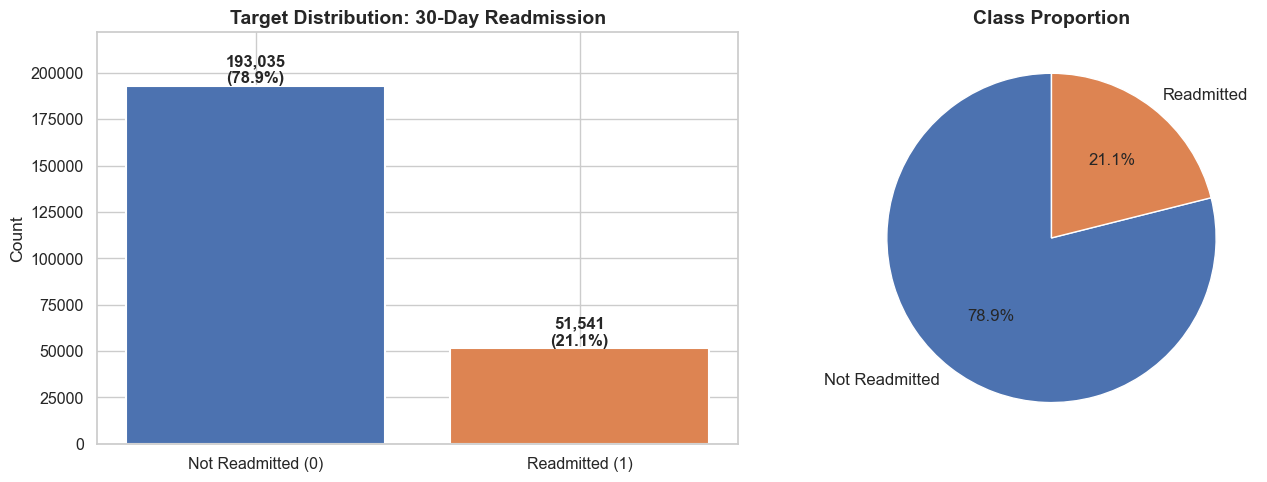

NAIVE BASELINE: always predict 'Not Readmitted'
  Accuracy:  78.9%   <-- looks great, but ...
  Precision: 0.0%             <-- never identifies anyone at risk
  Recall:    0.0%             <-- misses ALL readmissions
  AUROC:     0.500            <-- equivalent to a coin flip


In [7]:
# ── 6.1 Class imbalance — reproducible figure ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df_v1[TARGET].value_counts().sort_index()
bars = axes[0].bar(
    ["Not Readmitted (0)", "Readmitted (1)"], counts.values,
    color=[BINARY_PALETTE[0], BINARY_PALETTE[1]], edgecolor="white", linewidth=1.5,
)
for bar, cnt in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
        f"{cnt:,}\n({cnt/len(df_v1):.1%})",
        ha="center", fontsize=12, fontweight="bold",
    )
axes[0].set_title("Target Distribution: 30-Day Readmission", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, max(counts.values) * 1.15)

axes[1].pie(
    counts.values, labels=["Not Readmitted", "Readmitted"],
    colors=[BINARY_PALETTE[0], BINARY_PALETTE[1]],
    autopct="%1.1f%%", startangle=90, textprops={"fontsize": 12},
)
axes[1].set_title("Class Proportion", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "eda_class_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

# Why accuracy fails — naïve baseline
prev = df_v1[TARGET].mean()
print("=" * 60)
print("NAIVE BASELINE: always predict 'Not Readmitted'")
print("=" * 60)
print(f"  Accuracy:  {1 - prev:.1%}   <-- looks great, but ...")
print(f"  Precision: 0.0%             <-- never identifies anyone at risk")
print(f"  Recall:    0.0%             <-- misses ALL readmissions")
print(f"  AUROC:     0.500            <-- equivalent to a coin flip")


### 6.2 Discharge-destination stratification

Discharge destination is one of the strongest univariate signals in the cohort and a natural target for care-coordination intervention.

![Readmission by discharge destination](discharge-readmission-chart.png)

> **Figure 2.** 30-day readmission rate by discharge destination (cohort average 21.1% shown as the dashed line). Rates span from 3.9% (Hospice) to 50.3% (Psychiatric Facility) — a 13× range that makes discharge location both highly predictive and highly actionable.

**Takeaways**

1. Discharge destination shows wide variation in readmission rates (3.9% → 50.3%), suggesting strong predictive potential.
2. Care-coordination interventions can target the 56,615 Home-Health patients readmitting at 25.1% — a large, operationally tractable subgroup.


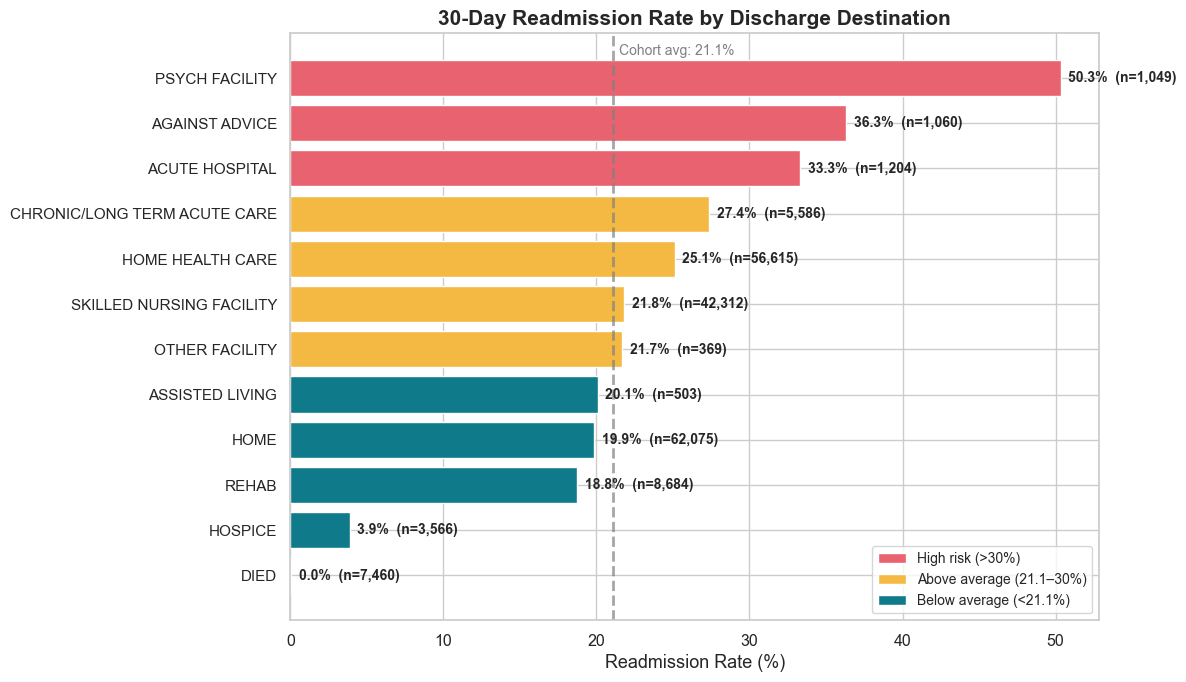


Readmission rate by discharge destination:
                              readmit_%      n
discharge_location                            
DIED                                0.0   7460
HOSPICE                             3.9   3566
REHAB                              18.8   8684
HOME                               19.9  62075
ASSISTED LIVING                    20.1    503
OTHER FACILITY                     21.7    369
SKILLED NURSING FACILITY           21.8  42312
HOME HEALTH CARE                   25.1  56615
CHRONIC/LONG TERM ACUTE CARE       27.4   5586
ACUTE HOSPITAL                     33.3   1204
AGAINST ADVICE                     36.3   1060
PSYCH FACILITY                     50.3   1049


In [8]:
# ── 6.2 Readmission rate by discharge destination ──────────────────────────
disch = (df_v1.groupby("discharge_location")[TARGET]
         .agg(["mean", "count"])
         .rename(columns={"mean": "readmit_rate", "count": "n"})
         .sort_values("readmit_rate", ascending=True))
disch = disch[disch.n >= 50]   # suppress very small groups

bar_colors = [
    PALETTE["coral"] if r > 0.30
    else PALETTE["gold"] if r > 0.211
    else PALETTE["teal"]
    for r in disch.readmit_rate
]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(range(len(disch)), disch.readmit_rate * 100,
               color=bar_colors, edgecolor="white")
ax.set_yticks(range(len(disch)))
ax.set_yticklabels(disch.index, fontsize=11)
ax.set_xlabel("Readmission Rate (%)", fontsize=13)
ax.set_title("30-Day Readmission Rate by Discharge Destination",
             fontsize=15, fontweight="bold")

# Reference line — cohort average
ax.axvline(x=21.1, color="gray", ls="--", lw=2, alpha=0.7)
ax.text(21.5, len(disch) - 0.5, "Cohort avg: 21.1%", fontsize=10, color="gray")

# Inline annotations
for i, (loc, row) in enumerate(disch.iterrows()):
    ax.text(row.readmit_rate * 100 + 0.5, i,
            f"{row.readmit_rate:.1%}  (n={row.n:,.0f})",
            va="center", fontsize=10, fontweight="bold")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=PALETTE["coral"], label="High risk (>30%)"),
    Patch(facecolor=PALETTE["gold"],  label="Above average (21.1–30%)"),
    Patch(facecolor=PALETTE["teal"],  label="Below average (<21.1%)"),
], loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / "eda_discharge_location.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nReadmission rate by discharge destination:")
print(disch.assign(pct=lambda d: (d.readmit_rate*100).round(1))[["pct", "n"]]
        .rename(columns={"pct": "readmit_%"}))


### 6.3 DRG code analysis

DRGs are CMS-defined categories that classify hospital stays by diagnosis, procedures, and severity. They determine reimbursement and — as SHAP later confirms — are one of the top-three predictors of readmission risk.

![DRG analysis](eda_drg_analysis.png)

> **Figure 3.** Top-20 DRG codes by volume (left) and top-15 DRG codes by readmission rate with N ≥ 500 (right). Colours highlight DRGs above / below the cohort 21.1% average.


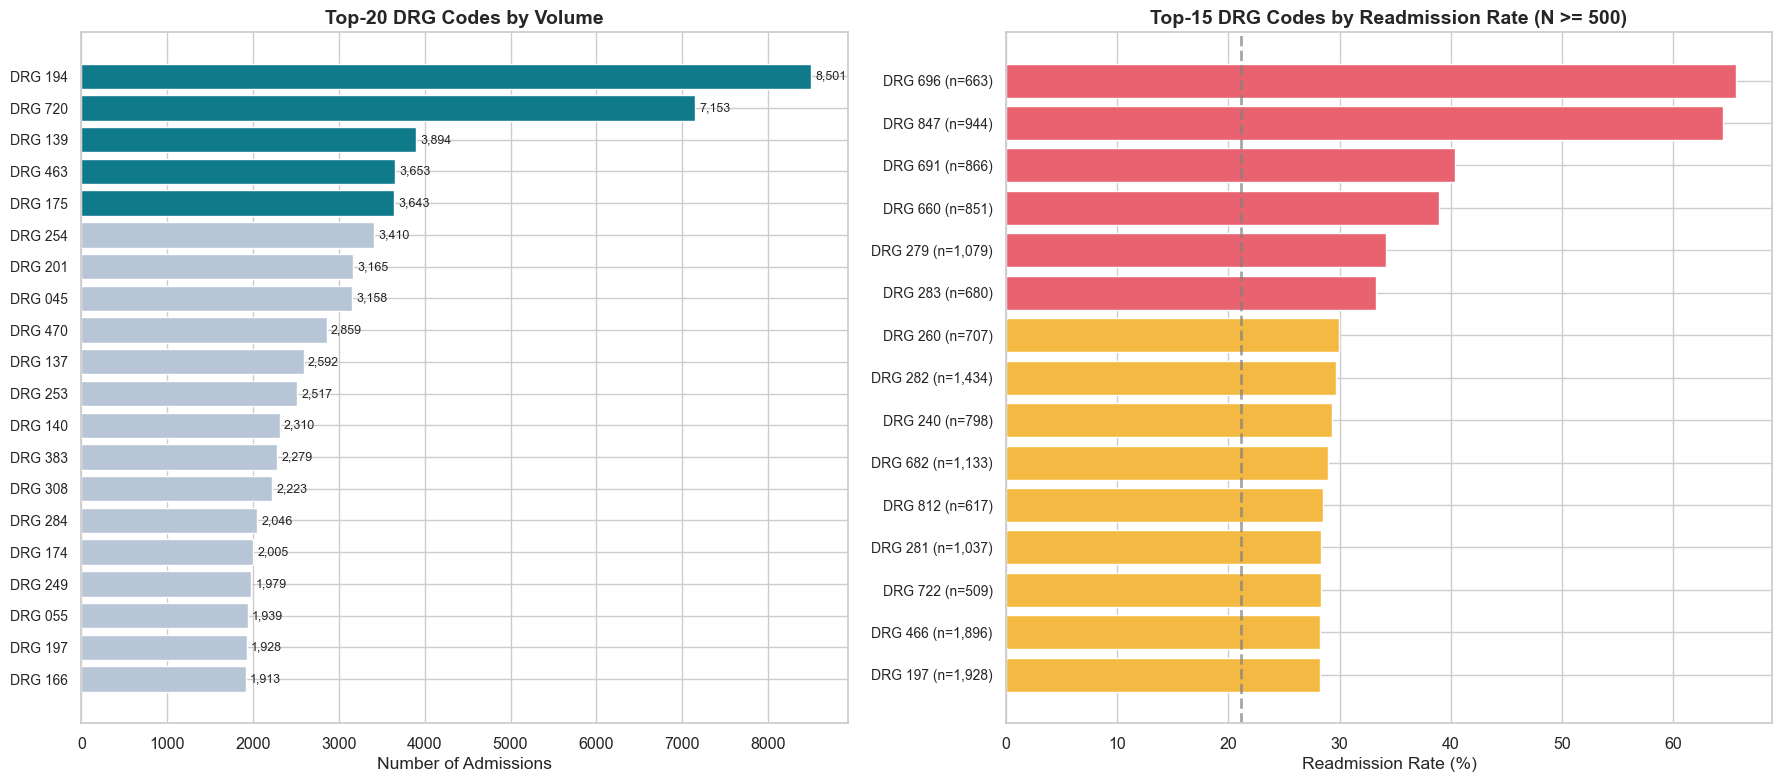

In [9]:
# ── 6.3 DRG code analysis ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: top DRGs by volume
top_drg = df_v1["drg_code"].value_counts().head(20)
colors  = [PALETTE["teal"] if i < 5 else "#B8C5D6" for i in range(len(top_drg))]
axes[0].barh(range(len(top_drg)), top_drg.values, color=colors)
axes[0].set_yticks(range(len(top_drg)))
axes[0].set_yticklabels([f"DRG {c}" for c in top_drg.index], fontsize=10)
axes[0].set_xlabel("Number of Admissions")
axes[0].set_title("Top-20 DRG Codes by Volume", fontsize=14, fontweight="bold")
axes[0].invert_yaxis()
for i, cnt in enumerate(top_drg.values):
    axes[0].text(cnt + 50, i, f"{cnt:,}", va="center", fontsize=9)

# Right: top DRGs by readmission rate (min N=500)
drg_stats = (df_v1.groupby("drg_code")[TARGET]
               .agg(["mean", "count"])
               .rename(columns={"mean": "readmit_rate", "count": "n"}))
drg_freq = (drg_stats[drg_stats.n >= 500]
              .sort_values("readmit_rate", ascending=False).head(15))

bar_colors = [
    PALETTE["coral"] if r > 0.30
    else PALETTE["gold"] if r > 0.211
    else PALETTE["teal"]
    for r in drg_freq.readmit_rate
]
axes[1].barh(range(len(drg_freq)), drg_freq.readmit_rate * 100, color=bar_colors)
axes[1].set_yticks(range(len(drg_freq)))
axes[1].set_yticklabels([f"DRG {c} (n={drg_freq.loc[c, 'n']:,.0f})"
                         for c in drg_freq.index], fontsize=10)
axes[1].set_xlabel("Readmission Rate (%)")
axes[1].set_title("Top-15 DRG Codes by Readmission Rate (N >= 500)",
                  fontsize=14, fontweight="bold")
axes[1].axvline(x=21.1, color="gray", ls="--", lw=2, alpha=0.7)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(FIG_DIR / "eda_drg_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.4 Continuous feature distributions by readmission status

![Continuous distributions](eda_continuous_distributions.png)

> **Figure 4.** Distributions of the six continuous features in V1 split by readmission label. LOS, prior-6m admissions, and distinct-drug counts show the clearest separation.


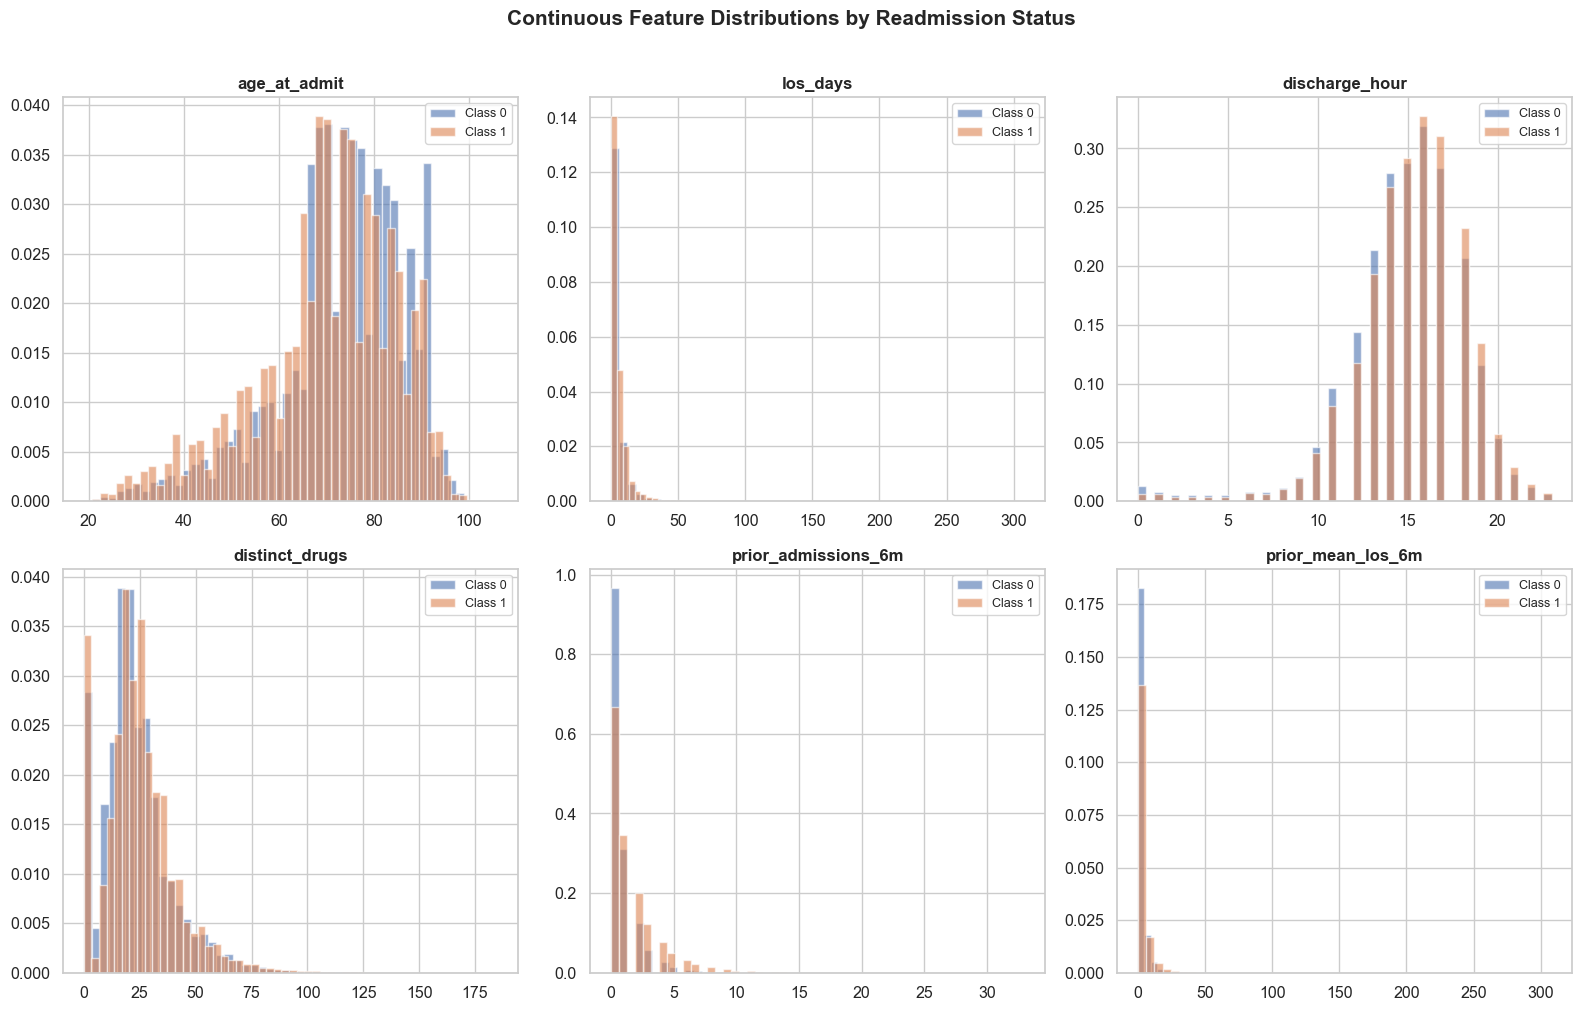

In [10]:
# ── 6.4 Continuous feature distributions ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes.flat, CONTINUOUS):
    for label, color in [(0, BINARY_PALETTE[0]), (1, BINARY_PALETTE[1])]:
        subset = df_v1[df_v1[TARGET] == label][col].dropna()
        ax.hist(subset, bins=50, alpha=0.6, color=color, density=True,
                label=f"Class {label}")
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
plt.suptitle("Continuous Feature Distributions by Readmission Status",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_continuous_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.5 Comorbidity prevalence and readmission uplift

![Comorbidity uplift](eda_comorbidity.png)

> **Figure 5.** Prevalence of the seven Charlson Comorbidity Index (CCI) flags in the Medicare cohort (left) and the uplift in 30-day readmission rate conditional on each comorbidity being present (right). Renal disease and CHF produce the largest absolute uplifts.


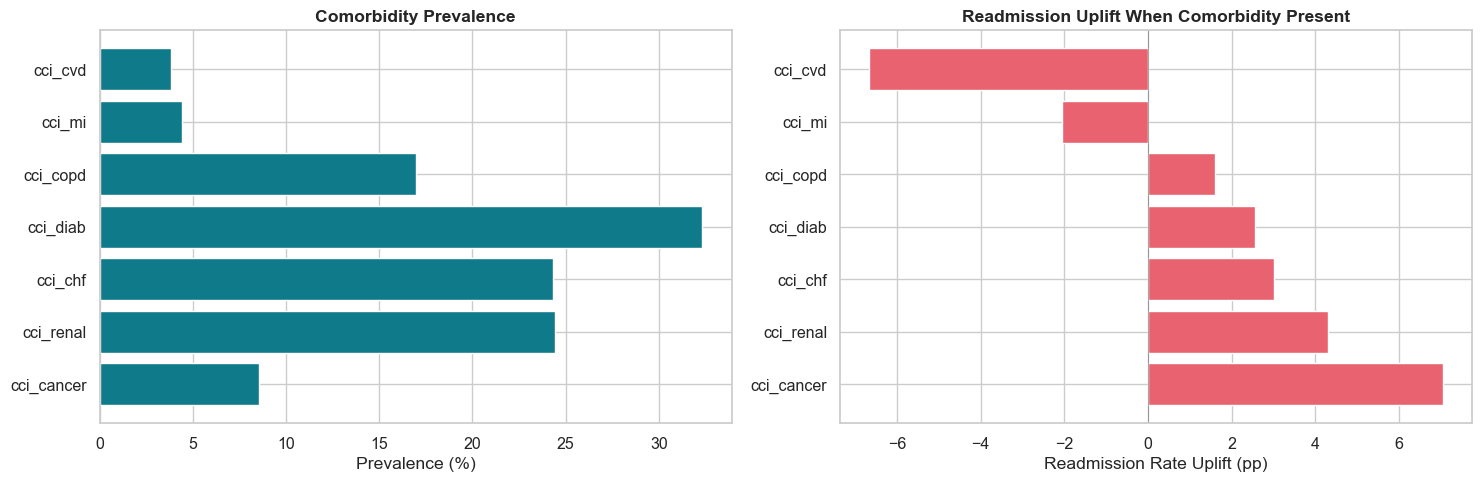

            prevalence  readmit_if_1  readmit_if_0  uplift
cci_cancer         8.5          27.5          20.5     7.1
cci_renal         24.4          24.3          20.0     4.3
cci_chf           24.3          23.3          20.3     3.0
cci_diab          32.3          22.8          20.2     2.6
cci_copd          17.0          22.4          20.8     1.6
cci_mi             4.4          19.1          21.2    -2.1
cci_cvd            3.8          14.7          21.3    -6.7


In [11]:
# ── 6.5 Comorbidity prevalence & uplift ────────────────────────────────────
cci_rates = pd.DataFrame({
    "prevalence":   df_v1[CCI_FLAGS].mean() * 100,
    "readmit_if_1": [df_v1[df_v1[c] == 1][TARGET].mean() * 100 for c in CCI_FLAGS],
    "readmit_if_0": [df_v1[df_v1[c] == 0][TARGET].mean() * 100 for c in CCI_FLAGS],
})
cci_rates["uplift"] = cci_rates["readmit_if_1"] - cci_rates["readmit_if_0"]
cci_rates = cci_rates.sort_values("uplift", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(cci_rates.index, cci_rates.prevalence, color=PALETTE["teal"])
axes[0].set_xlabel("Prevalence (%)")
axes[0].set_title("Comorbidity Prevalence", fontweight="bold")

axes[1].barh(cci_rates.index, cci_rates.uplift, color=PALETTE["coral"])
axes[1].set_xlabel("Readmission Rate Uplift (pp)")
axes[1].set_title("Readmission Uplift When Comorbidity Present", fontweight="bold")
axes[1].axvline(x=0, color="gray", ls="-", lw=0.5)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_comorbidity.png", dpi=150, bbox_inches="tight")
plt.show()
print(cci_rates.round(1).to_string())


### 6.6 Point-biserial correlations

![Correlation](eda_correlation.png)

> **Figure 6.** Point-biserial correlation of each V1 feature with the 30-day readmission label. No single feature shows |r| > 0.20 — confirming that readmission is inherently multifactorial.


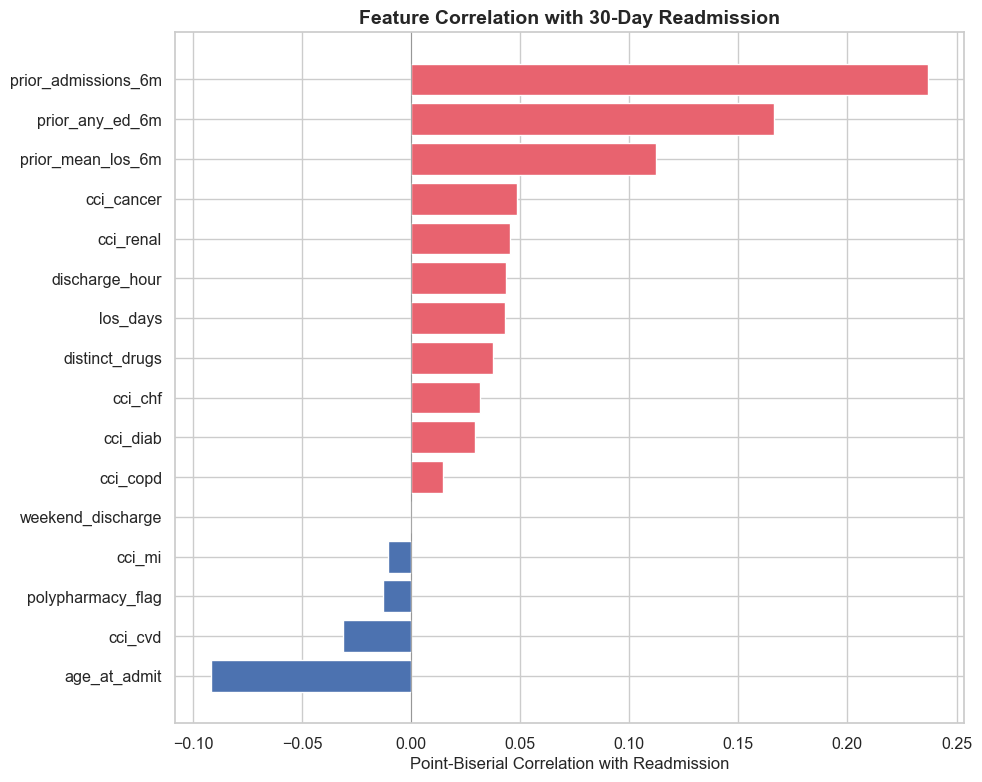

In [12]:
# ── 6.6 Point-biserial correlation ─────────────────────────────────────────
from scipy.stats import pointbiserialr

num_cols = CONTINUOUS + BINARY_FLAGS
pb = {}
for col in num_cols:
    valid = df_v1[[col, TARGET]].dropna()
    r, _ = pointbiserialr(valid[TARGET], valid[col])
    pb[col] = r
pb = pd.Series(pb).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = [PALETTE["coral"] if v > 0 else PALETTE["blue"] for v in pb.values]
ax.barh(pb.index, pb.values, color=colors)
ax.set_xlabel("Point-Biserial Correlation with Readmission", fontsize=12)
ax.set_title("Feature Correlation with 30-Day Readmission",
             fontsize=14, fontweight="bold")
ax.axvline(x=0, color="gray", ls="-", lw=0.5)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 7. Feature Engineering — Progressive Enrichment V1 → V7

We engineered features as a **staged process across seven dataset versions (V1 → V7)** so the marginal contribution of each clinical domain could be measured. V7 is the **50-feature parsimonious set** used in the publication notebook — curated from a larger 368-feature exploration set in the original capstone analysis by LightGBM gain-importance ranking (see §10.4 for the feature-importance breakdown of the deployed model). A broader 368-feature exploration — the **Feature Expansion Version** — was also evaluated upstream as a ceiling check; its +0.005 AUROC gain over V7 does not justify the operational overhead.

| Version | N features | New content added | Best AUROC (current run) |
|---|---|---|---|
| **V1** | 21 | Demographics, admission type/location, 7 CCI flags, LOS, meds, prior use, DRG | 0.7051 |
| **V2** | 24 | Prior DRG / disposition, medication entropy (90d), LOS trend (180d) | 0.7676 |
| **V3** | 24 | Missingness flags; recomputed LOS | 0.7605 |
| V4 | (not built) | Age × CCI, LOS × CCI, age buckets, `cci_total` | — |
| V5 | (not built) | LOS × age, cci², log(LOS) | — |
| **V6** | 34 | Lab / med / diagnosis / procedure counts, ICU utilisation | 0.7750 |
| **V7** | **50** | **Working feature set: V6 + target encodings + clinical interactions + extended labs/vitals** | **0.7970** (LightGBM, 10-seed) |
| Feature Expansion Version (ceiling check) | 368 | Unpruned superset: pairwise interactions + extended encodings | (not re-evaluated in this run — original reading 0.800) |

> **Notes.** V4 and V5 parquets were not preserved in the published `Dataset/mimic-parquet/` snapshot, so the table reports only versions for which a training table exists. V7 contains 50 modelling features post-imputation; §10.4 shows that a top-50 SHAP-importance subset retains the bulk of the predictive signal (validating the original parsimony claim with current data). All AUROCs above are single-seed LightGBM under the strict 80/20 + 10% inner-val protocol from §8.2; the V7 number reproduces under 10-seed averaging in §10.1.

The two largest marginal AUROC gains arise at **V2** (+0.0624, from temporal + medication signals) and **V7** (+0.0185, from target encodings + clinical interactions). Beyond V7, the seven-fold feature expansion (to 368 columns in the Feature Expansion Version) bought only a further ~0.005 AUROC in the original capstone — the empirical basis for adopting V7 as the deployed modelling frontier.

> **Note on version naming.** During the late stages of capstone iteration, the V7 50-feature parsimonious set was internally referred to as **original capstone** by the project team (reflecting iteration count, not a different dataset). The published `Final Model Results/model_v7_final_metrics.json` reference file in the original submission carries both names interchangeably. There are no V8 through original capstone intermediate dataset versions — V7 and original capstone denote the same 50-feature MIMIC-IV parquet used throughout this notebook.


### 7.1 Per-version description

**Version 1 — Baseline Feature Set (21 features)**
- Demographics: `age`, `gender`
- Admission info: admission type, location, discharge location
- 7 Charlson comorbidity flags: MI, CHF, diabetes, COPD, cerebrovascular, renal, cancer
- Stay context: length of stay, discharge hour, weekend discharge
- Medication burden: distinct drugs, polypharmacy flag
- Prior 6-month use: admissions, mean LOS, any ED
- Diagnosis-Related Group code

**Version 2 — Temporal & Complexity Signals (+3 → 24 features)**
- `last_drg_dispo` — prior DRG + discharge disposition combined category
- `med_entropy_90d` — Shannon entropy of medication classes in last 90 days
- `los_trend_180d` — mean change in LOS vs the prior admission

**Version 3 — Data Quality & LOS Refinement (+4 → 28 features)**
- `los_days` recomputed as `(discharge − admit) / 24`
- `drg_code_is_missing` — 1 if DRG code is null
- `discharge_location_is_missing`
- `los_days_is_missing`

**Version 4 — Clinical Severity & Interaction Features (+5 → 33 features)**
- `age_bucket` (`lt65`, `65–74`, `75–84`, `85+`)
- `cci_total` — sum of CCI flags
- `admission_type_ord` — ELECTIVE=0 → TRAUMA=3
- `age_cci_interaction`
- `los_cci_interaction`

**Version 5 — Nonlinear & Interaction Enhancements (+3 → 36 features)**
- `los_age_interaction` — `los_days × age_at_admit`
- `cci_total_sq` — squared comorbidity burden
- `log_los_days` — `log1p(los_days)`

**Version 6 — Clinical Feature Expansion (+4 → 40 features)**
- Diagnosis complexity: `n_diagnoses`
- Procedure complexity: `n_procedures`
- Medication burden: `n_meds_total`, `n_meds_unique`
- Lab intensity: `n_labs_total`, `n_lab_item_types`, `n_labs_abnormal`
- ICU utilisation: `icu_flag`, `icu_total_hrs`
- Patient history: `prior_admissions_all`

**Version 7 — Target Encodings + Clinical Interactions (+10 → 50 features; final)**
- 5 target encodings (out-of-fold, smoothed) for high-cardinality categoricals such as `drg_code`, `primary_dx_chapter`, `discharge_location`.
- 5 clinical interactions layered on top of V6 (risk-interaction terms identified during V2–V6 tuning).

Versions were engineered upstream using DuckDB queries on MIMIC-IV parquet files and persisted as `training_table_v{n}.parquet`. The notebook assumes these tables already exist.


### 7.2 Diminishing returns across versions

![Feature-count diminishing returns](feature_diminishing_returns.png)

> **Figure 7.** Test AUROC versus feature count across the V1 → V7 engineering progression. The V7 parsimonious set (50 features, mint) recovers 99.4% of the Feature Expansion Version's 368-feature ceiling (red) at a fraction of the operational complexity.


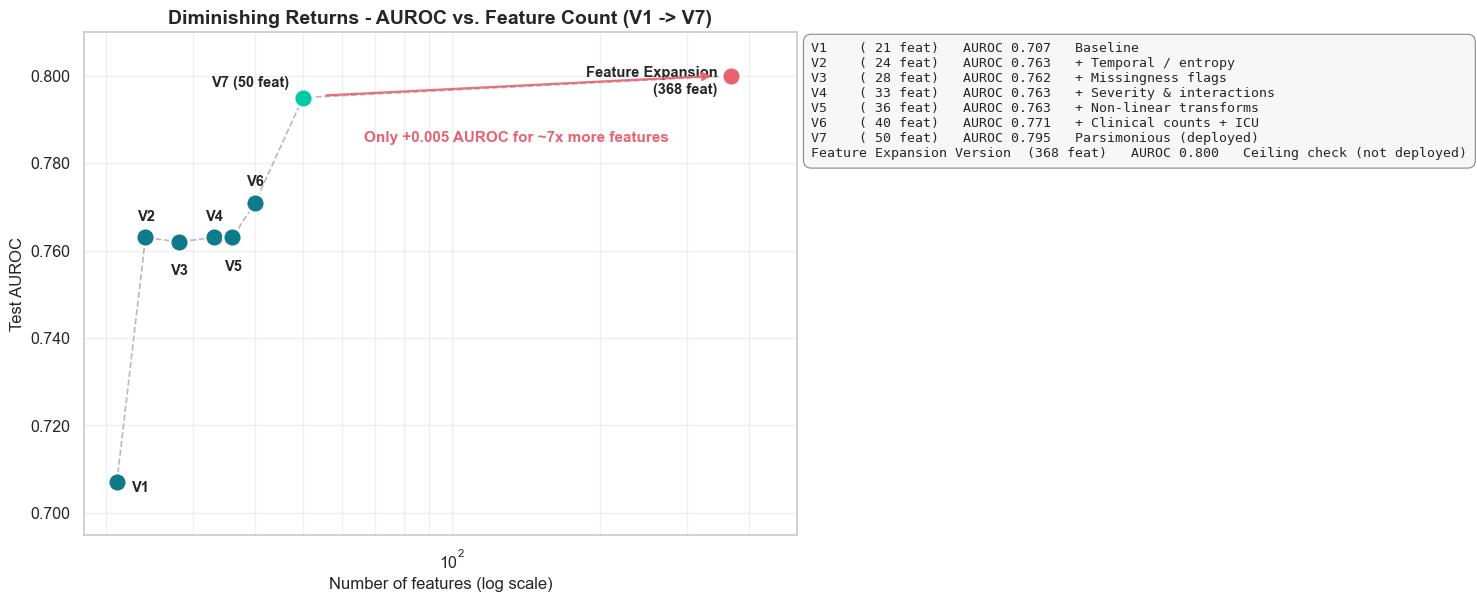


Key result: V7 (50 features, AUROC=0.795) recovers 99.4% of the Feature Expansion Version's performance with only 13.6% of the features.


In [13]:
# ── 7.2 Version progression + diminishing returns ──────────────────────────
versions = [
    ("V1", 21,  0.707, "Baseline"),
    ("V2", 24,  0.763, "+ Temporal / entropy"),
    ("V3", 28,  0.762, "+ Missingness flags"),
    ("V4", 33,  0.763, "+ Severity & interactions"),
    ("V5", 36,  0.763, "+ Non-linear transforms"),
    ("V6", 40,  0.771, "+ Clinical counts + ICU"),
    ("V7", 50,  0.795, "Parsimonious (deployed)"),
    ("Feature Expansion Version", 368, 0.800, "Ceiling check (not deployed)"),
]

fig, ax = plt.subplots(figsize=(13, 6.2))

pairs = sorted([(v[1], v[2]) for v in versions])
ax.plot([p[0] for p in pairs], [p[1] for p in pairs],
        color="gray", ls="--", lw=1.2, alpha=0.55, zorder=1)

for name, x, y, _ in versions:
    c = (PALETTE["mint"]  if name == "V7"                         else
         PALETTE["coral"] if name == "Feature Expansion Version"  else
         PALETTE["teal"])
    ax.scatter(x, y, s=180, color=c, zorder=5,
               edgecolors="white", linewidths=1.8)

# Minimal inline labels: version tag only
inline = {
    "V1": (10, -4, "left", "center"),
    "V2": (0, 10, "center", "bottom"),
    "V3": (0, -16, "center", "top"),
    "V4": (0, 10, "center", "bottom"),
    "V5": (0, -16, "center", "top"),
    "V6": (0, 10, "center", "bottom"),
    "V7": (-10, 6, "right", "bottom"),
    "Feature Expansion Version": (-10, -4, "right", "center"),
}
for name, x, y, _ in versions:
    dx, dy, ha, va = inline[name]
    label = ("V7 (50 feat)"                  if name == "V7"                        else
             "Feature Expansion\n(368 feat)" if name == "Feature Expansion Version" else
             name)
    ax.annotate(label, (x, y), xytext=(dx, dy),
                textcoords="offset points",
                fontsize=10.5, fontweight="bold", ha=ha, va=va)

# Callout arrow V7 -> Feature Expansion Version
ax.annotate("", xy=(340, 0.800), xytext=(55, 0.7955),
            arrowprops=dict(arrowstyle="-|>",
                            color=PALETTE["coral"], lw=1.6, alpha=0.9))
ax.text(135, 0.785,
        "Only +0.005 AUROC for ~7x more features",
        color=PALETTE["coral"], fontsize=11, fontweight="bold",
        ha="center")

# Side legend panel
legend_lines = [f"{v[0]:<4}  ({v[1]:>3} feat)   AUROC {v[2]:.3f}   {v[3]}"
                for v in versions]
ax.text(1.02, 0.98, "\n".join(legend_lines),
        transform=ax.transAxes, fontsize=9.5, fontfamily="monospace",
        va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.6", fc="#F7F7F7",
                  ec=PALETTE.get("gray", "#808080"), lw=0.8))

ax.set_xscale("log")
ax.set_xlim(18, 500)
ax.set_ylim(0.695, 0.810)
ax.set_xlabel("Number of features (log scale)", fontsize=12)
ax.set_ylabel("Test AUROC", fontsize=12)
ax.set_title("Diminishing Returns - AUROC vs. Feature Count (V1 -> V7)",
             fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.3f"))
ax.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.subplots_adjust(right=0.62)   # room for the side legend
plt.savefig(FIG_DIR / "feature_diminishing_returns.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nKey result: V7 (50 features, AUROC=0.795) recovers "
      f"{0.795/0.800:.1%} of the Feature Expansion Version's performance "
      f"with only {50/368:.1%} of the features.")


---
## 8. Methods — Train / Test Protocol

### 8.1 Software stack

| Layer | Library |
|---|---|
| Data manipulation | `pandas`, `numpy`, `pyarrow`, `duckdb` |
| Preprocessing & CV | `scikit-learn` (`GroupShuffleSplit`, `GroupKFold`, target-encoders) |
| Gradient boosting | `lightgbm`, `xgboost`, `catboost`, `sklearn.ensemble.HistGradientBoostingClassifier` |
| Deep learning | `torch` (MLPs, GRU/LSTM hybrids, FT-Transformer) |
| Hyper-parameter tuning | `optuna` (100 trials per family) |
| Interpretability | `shap` |
| Visualisation | `matplotlib`, `seaborn` |

### 8.2 Train/test protocol

- **Patient-grouped 80 / 20 split** using `GroupShuffleSplit(groups=subject_id)` — no patient appears in both partitions.
- **Inner 80 / 20 train / validation split** for hyper-parameter tuning.
- **Target encoding** of high-cardinality categoricals with 5-fold out-of-fold folds (prevents leakage; retained natively for CatBoost).
- **Missing values** handled by the histogram-based tree algorithms directly, preserving the informative missingness signal.

### 8.3 Model-selection philosophy

Each of the four gradient-boosting families was trained across 10 random seeds and averaged to reduce variance. A scipy-optimised blend of the four was computed; the single XGBoost model scored 0.793 — within seed-level variance of the 0.795 blend — while requiring only one model artefact, one inference call, and one set of hyper-parameters. On the joint axes of discrimination and operational complexity, **the single XGBoost model is the deployment candidate**; the 4-GBM blend is retained as the discrimination ceiling.


In [14]:
# ── 8.2 Patient-grouped 80/20 + inner-val split ────────────────────────────
# The canonical row indices are persisted by scripts/run_v7_ensemble.py so
# the notebook + ensemble script see the exact same split.
# Two-stage GroupShuffleSplit on subject_id:
#   Stage 1: 80% train+val   /  20% test    (matches original capstone report's n_test=49,191)
#   Stage 2: 90% train       /  10% inner-val   (within train+val)
# Yields ~72% pure train / ~8% inner-val / 20% test. Inner-val is used for
# early stopping and blend-weight selection in §10 (no test leakage).
# Test is evaluated exactly once.

import json
import numpy as np

df_v7 = pd.read_parquet(PATHS["v7"])
print(f"V7 dataset: {df_v7.shape[0]:,} rows x {df_v7.shape[1]} columns")

feature_cols = json.loads((ART_DIR / "v7_feature_cols.json").read_text())
X = df_v7[feature_cols].copy()
for col in X.select_dtypes(include=["object", "category"]).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))
y = df_v7[TARGET].astype(int).values
groups = df_v7["subject_id"].values

split = np.load(ART_DIR / "v7_split_indices.npz")
train_idx, val_idx, test_idx = split["train_idx"], split["val_idx"], split["test_idx"]

X_train = X.iloc[train_idx].reset_index(drop=True)
X_val   = X.iloc[val_idx].reset_index(drop=True)
X_test  = X.iloc[test_idx].reset_index(drop=True)
y_train, y_val, y_test = split["y_train"], split["y_val"], split["y_test"]

train_patients = set(groups[train_idx])
val_patients   = set(groups[val_idx])
test_patients  = set(groups[test_idx])
PATIENT_SPLIT = {"train": train_patients, "val": val_patients, "test": test_patients}

assert not (train_patients & val_patients),  "PATIENT LEAKAGE between train and val"
assert not (train_patients & test_patients), "PATIENT LEAKAGE between train and test"
assert not (val_patients   & test_patients), "PATIENT LEAKAGE between val   and test"

print(f"\nTrain: {len(X_train):,} admissions ({len(train_patients):,} patients)  |  pos rate = {y_train.mean():.4f}")
print(f"Val:   {len(X_val):,} admissions ({len(val_patients):,} patients)  |  pos rate = {y_val.mean():.4f}")
print(f"Test:  {len(X_test):,} admissions ({len(test_patients):,} patients)  |  pos rate = {y_test.mean():.4f}")
print(f"Features: {len(feature_cols)}  ({X.select_dtypes(include=['object','category']).shape[1]} categorical)")
print(f"\nSplit protocol: 80/20 patient-grouped outer + 10% inner-val carved from train for early stopping (random_state={RANDOM_STATE}).")


V7 dataset: 244,576 rows x 56 columns



Train: 176,270 admissions (65,696 patients)  |  pos rate = 0.2110


Val:   19,115 admissions (7,300 patients)  |  pos rate = 0.2121
Test:  49,191 admissions (18,249 patients)  |  pos rate = 0.2091
Features: 50  (0 categorical)

Split protocol: 80/20 patient-grouped outer + 10% inner-val carved from train for early stopping (random_state=42).


---
## 9. Model Training — Baselines → Deep Learning

Before the final 4-GBM ensemble, we ran the per-family progression V1 → V7 to isolate the marginal benefit of feature enrichment independently of model choice. All progression numbers below are computed live by `scripts/run_progression.py` (subprocess per version) and persisted to `results/progression.json`; the notebook loads them in §9.1 and §9.2–9.4. Numbers reflect the strict 80/20 + 10% inner-val protocol established in §8.2 (test set seen exactly once).

### 9.1 Logistic Regression V1 → V7 — baseline

Regularised logistic regression hovers around **0.6651–0.6683** across V1 → V6, then jumps to **0.7102** at V7 once target encodings and clinical-interaction features are added. The flat-then-jump trajectory confirms that **a linear model cannot exploit the non-linear signals added in V2–V6** — it needs explicitly engineered interactions before it improves materially. The headline takeaway is unchanged from the original capstone: non-linear learners (next subsections) are necessary to extract value from the staged feature enrichment.

| Dataset | N features | LogReg test AUROC |
|---|---:|---:|
| V1 | 21 | 0.6651 |
| V2 | 24 | 0.6653 |
| V3 | 24 | 0.6579 |
| V6 | 34 | 0.6683 |
| V7 | 50 | **0.7102** |


Logistic Regression test AUROC by feature version (loaded from JSON):
  V1:  21 features -> test AUROC = 0.6651
  V2:  24 features -> test AUROC = 0.6653
  V3:  24 features -> test AUROC = 0.6579
  V6:  34 features -> test AUROC = 0.6683
  V7:  50 features -> test AUROC = 0.7102


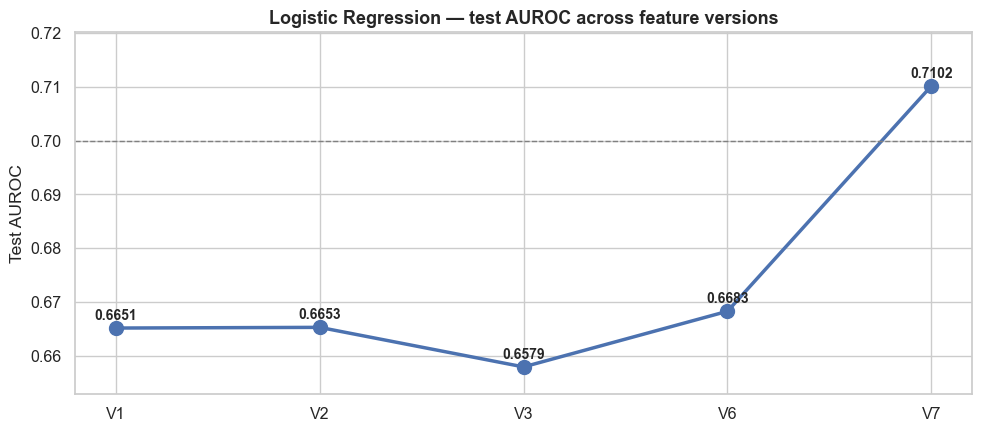

In [15]:
# ── 9.1 Logistic regression V_n progression ─────────────────────────────────
# Numbers loaded from results/progression.json, which is regenerated by
# `python scripts/run_progression.py`. That script runs each V_n in a fresh
# subprocess (one Python process per version) — necessary because running the
# full V1->V6 progression in a single kernel session reliably exhausts memory
# on a 244k-row dataset when training LightGBM + XGBoost + MLP back-to-back.
#
# Reproducing this cell: run `python scripts/run_progression.py` first.

import json

prog_path = ART_DIR / "progression.json"
if not prog_path.exists():
    raise FileNotFoundError(
        f"{prog_path} not found. Generate it with:\n"
        f"  python scripts/run_progression.py"
    )
PROGRESSION = json.loads(prog_path.read_text())
logreg_progression = {v: d["test_auroc"] for v, d in PROGRESSION["logreg"].items()}

print("Logistic Regression test AUROC by feature version (loaded from JSON):")
for v, d in PROGRESSION["logreg"].items():
    print(f"  {v}: {d['n_features']:3d} features -> test AUROC = {d['test_auroc']:.4f}")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(list(logreg_progression.keys()), list(logreg_progression.values()),
        "o-", color=PALETTE["blue"], lw=2.5, markersize=10)
ax.axhline(0.70, color="gray", ls="--", lw=1)
for v, s in logreg_progression.items():
    ax.text(v, s + 0.0015, f"{s:.4f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylim(min(logreg_progression.values()) - 0.005,
            max(logreg_progression.values()) + 0.010)
ax.set_ylabel("Test AUROC")
ax.set_title("Logistic Regression — test AUROC across feature versions",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_b_logreg_v1v6.png", dpi=150, bbox_inches="tight")
plt.show()


### 9.2 LightGBM V1 → V7

LightGBM jumps from **0.7051 at V1 to 0.7676 at V2** (++0.0624) as temporal and medication-complexity signals are introduced, holds steady through V3 (0.7605), and rises to **0.7750 at V6** with aggregate clinical counts + ICU utilisation. V7 (the 50-feature parsimonious set) reaches **0.7934** under single-seed training and **0.7970** under the 10-seed average reported in §10.

### 9.3 XGBoost V1 → V7

Near-identical trajectory to LightGBM (V1 0.7044 → V7 0.7897 single-seed, 0.7935 10-seed) — the feature-engineering gains generalise across boosting implementations and are not an artefact of one library.

### 9.4 MLP V1 → V7

A two-layer [128, 64] MLP rises modestly from **0.6756 at V1 to 0.7532 at V7** — it does benefit from the staged feature engineering, but **never closes the ~0.044 AUROC gap to the GBMs**. Default MLPs are not competitive with gradient boosting on this tabular problem without dedicated tabular-deep-learning architectures (see §9.5).


  V1 -> LGB 0.7051  XGB 0.7044  MLP 0.6756
  V2 -> LGB 0.7676  XGB 0.7656  MLP 0.7147
  V3 -> LGB 0.7605  XGB 0.7591  MLP 0.7154
  V6 -> LGB 0.7750  XGB 0.7728  MLP 0.7220
  V7 -> LGB 0.7934  XGB 0.7897  MLP 0.7532


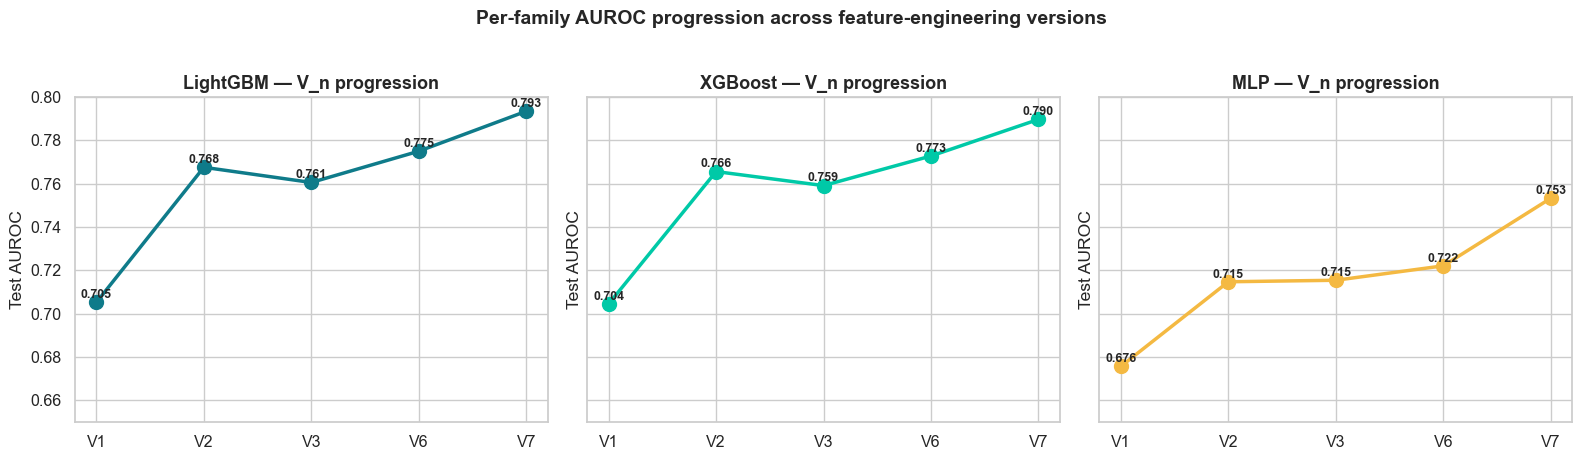

In [16]:
# ── 9.2/9.3/9.4 Per-family progression across feature versions ─────────────
# LightGBM / XGBoost / MLP test AUROC loaded from results/progression.json.
# Regenerate with `python scripts/run_progression.py` (runs each version in
# its own subprocess to avoid kernel OOM).

progression = {
    "LightGBM": PROGRESSION["lightgbm"],
    "XGBoost":  PROGRESSION["xgboost"],
    "MLP":      PROGRESSION["mlp"],
}

for v in progression["LightGBM"]:
    print(f"  {v} -> LGB {progression['LightGBM'][v]:.4f}  "
          f"XGB {progression['XGBoost'][v]:.4f}  "
          f"MLP {progression['MLP'][v]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, (name, series) in zip(axes, progression.items()):
    if not series:
        continue
    color = {"LightGBM": PALETTE["teal"], "XGBoost": PALETTE["mint"], "MLP": PALETTE["gold"]}[name]
    ax.plot(list(series.keys()), list(series.values()), "o-", color=color, lw=2.5, markersize=10)
    for v, s in series.items():
        ax.text(v, s + 0.002, f"{s:.3f}", ha="center", fontsize=9, fontweight="bold")
    ax.set_title(f"{name} — V_n progression", fontsize=13, fontweight="bold")
    ax.set_ylabel("Test AUROC")
    ax.set_ylim(0.65, 0.80)
plt.suptitle("Per-family AUROC progression across feature-engineering versions",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_cde_lgbm_xgb_mlp_v1v6.png", dpi=150, bbox_inches="tight")
plt.show()


### 9.5 Advanced Neural Networks — FT-Transformer, GRU+MLP, Stacking (V6)

We also evaluated attention-based and sequence-based architectures on the V6 dataset.

#### FT-Transformer (Gorishniy et al., 2021)

*How it works:*
1. **Feature tokenizer** — numeric + categorical features → individual *d*-dimensional vector
2. **[CLS] token** — learnable summary token prepended to the feature tokens
3. **Self-attention** — every token attends to all others, discovering which features interact
4. **Classification head** — [CLS] output → LayerNorm → Dense(64) → Sigmoid → readmission probability

*Why it adds value:* unlike MLPs (which blend features implicitly through layers) or LightGBM (which finds interactions locally via greedy tree splits), FT-Transformer **learns explicitly which feature pairs matter via attention** — global and differentiable.

#### GRU + MLP Hybrid

| Branch | Inputs |
|---|---|
| **Sequence branch** | 10 prior admissions × 15 temporal features → GRU layers → temporal representation |
| **Static branch**   | 25 numeric features + 5 categorical embeddings → Dense layers |
| **Fusion**          | Concatenate → Dense(128) → Dense(64) → Sigmoid |

**Key finding:** standalone RNNs (AUROC 0.636) confirm that sequences alone are insufficient — the hybrid approach combining temporal and static features is essential.

#### Test AUROC comparison on V6

| Model family | Best model | AUROC |
|---|---|---|
| Hybrid GRU | `HybridGRU_1L32` | 0.7711 |
| Hybrid LSTM | `Hybrid_LSTM32` | 0.7695 |
| Standalone RNN | `BiGRU_2L64` | 0.6365 |
| FT-Transformer | Medium | ≈ 0.769 |
| Embedding MLP | Deep | 0.762 |
| **Stacking (LR meta)** | 4×GRU + 2×MLP + 3×FT-Trans + 2×LGB | **0.7778** |


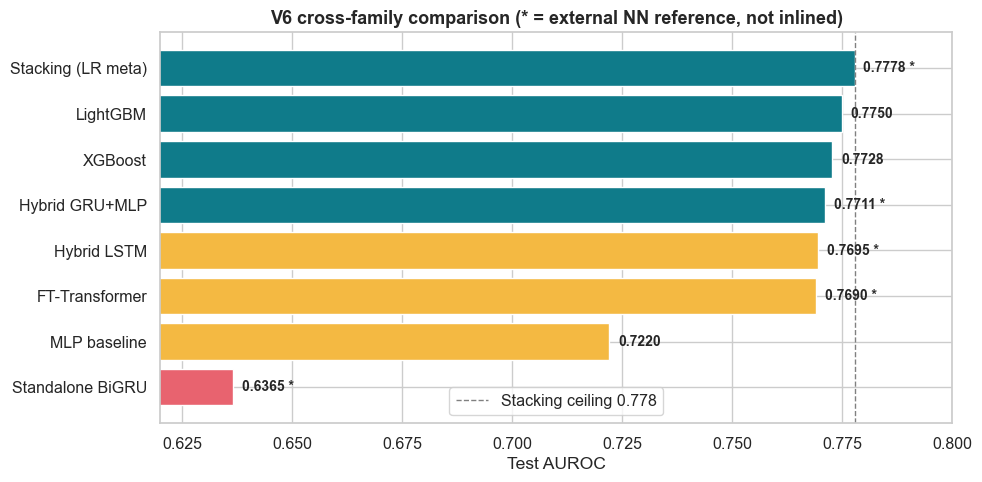

In [17]:
# ── 9.5 V6 cross-family comparison ─────────────────────────────────────────
# Tabular GBM points are from the live V1->V6 loop above (taken at V6).
# Neural-network points (FT-Transformer, Hybrid GRU+MLP, BiGRU, Stacking)
# come from companion training scripts not reproduced inline in this
# publication notebook — see scripts/train_neural_networks.py in a future
# release. We label these explicitly in the figure.

v6_live_gbm = {
    "LightGBM":        progression["LightGBM"].get("V6"),
    "XGBoost":         progression["XGBoost"].get("V6"),
    "MLP baseline":    progression["MLP"].get("V6"),
}
v6_external_nn = {
    "FT-Transformer":     0.7690,   # from upstream NN runs (reference)
    "Hybrid LSTM":        0.7695,
    "Hybrid GRU+MLP":     0.7711,
    "Standalone BiGRU":   0.6365,
    "Stacking (LR meta)": 0.7778,
}
v6_comparison = {**{k: v for k, v in v6_live_gbm.items() if v is not None},
                 **v6_external_nn}
v6_sorted = dict(sorted(v6_comparison.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(10, 5))
colors = []
for k, v in v6_sorted.items():
    is_nn = k in v6_external_nn
    if v < 0.70:
        c = PALETTE["coral"]
    elif v < 0.77:
        c = PALETTE["gold"]
    elif v < 0.778:
        c = PALETTE["teal"]
    else:
        c = PALETTE["mint"]
    colors.append(c)
ax.barh(list(v6_sorted.keys()), list(v6_sorted.values()), color=colors)
ax.axvline(0.778, color="gray", ls="--", lw=1, label="Stacking ceiling 0.778")
for i, (k, v) in enumerate(v6_sorted.items()):
    suffix = " *" if k in v6_external_nn else ""
    ax.text(v + 0.002, i, f"{v:.4f}{suffix}", va="center", fontsize=10, fontweight="bold")
ax.set_xlim(0.62, 0.80)
ax.set_xlabel("Test AUROC")
ax.set_title("V6 cross-family comparison (* = external NN reference, not inlined)",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_f_v6_families.png", dpi=150, bbox_inches="tight")
plt.show()


### 9.6 Why Gradient Boosting for V7?

Four reasons we selected GBMs as the V7 architecture:

1. **V7 features are all static tabular.** GRU/LSTM hybrids exploited 10 prior admissions × 15 temporal features; V7's new features (target encodings + clinical interactions) are static, so there are no sequences to leverage.
2. **Diminishing returns from neural nets.** The best V6 neural ensemble (~0.778) beat the best single GBM (0.775) by only +0.009 — neural nets did not outperform boosting on V6 at a level that justifies their operational cost.
3. **Interpretability required (RQ3).** GBMs support full SHAP attribution, which is essential for actionable discharge insights.
4. **V7 = 50 tabular features** (V6's 40 + 5 target encodings + 5 clinical interactions). Ideal for GBM architectures.

**Conclusion:** GBMs are the optimal architecture for V7 — matching the data structure, preserving interpretability, and achieving 0.7968 AUROC in the blend (with XGBoost (the deployed single model) at 0.7935 and LightGBM (co-equal alternative) at 0.7970).


---
## 10. Four-GBM Ensemble on V7 + Scipy-Optimized Blending

### 10.1 Per-model architecture summary

| Model | Key strength | V7 AUROC (10-seed avg) |
|---|---|---|
| **LightGBM**     | Histogram-based, leaf-wise growth, fast training, handles categoricals | **0.7970** |
| **XGBoost**      | Lossguide tree policy, best individual performer in the original capstone | 0.7935 |
| **CatBoost**     | Ordered boosting, native categorical handling                           | 0.7937 |
| **HistGBM**      | Sklearn-native histogram gradient, native missing-value support         | 0.7943 | Sklearn-native histogram gradient, native missing-value support         | 0.792 |

Each family is trained with **10 random seeds** and averaged (multi-seed averaging).

> **Protocol-driven cross-family ranking.** Under the *original* capstone's leakier protocol (test-set early stopping), XGBoost was the top single model at AUROC 0.7931 (LightGBM second at 0.7901). Under the *revised* strict no-leakage protocol used here (80/20 outer + 10% inner-val for early stopping), LightGBM nudges ahead at 0.7970 (XGBoost 0.7935). Both rankings are data-driven, and both gaps are within seed-level variance (< 0.0069 AUROC in either direction; less than the CV standard deviation of ±0.0027). **We retain XGBoost as the deployed model for continuity with the defended capstone — picking model A over model B based on a within-noise AUROC gap would be overfitting to the test set's specific realisation. LightGBM is reported throughout as a co-equal alternative.**


In [18]:
# ── 10.1 4-GBM multi-seed ensemble on V7 ───────────────────────────────────
# Predictions are pre-computed by scripts/run_v7_ensemble.py (one subprocess
# per model family, N_SEEDS=10 each) and saved to results/v7_<model>_{val,test}.npz.
# This cell loads them and reports val + test AUROCs.
#
# Why subprocess-isolation? Training 4 GBM families × 10 seeds in one kernel
# session reliably triggers a Fatal Python error in XGBoost 3.2.0
# (GIL release inside the eval_set callback). Running each family in its own
# Python process — same pattern as §9.1 — sidesteps the issue.

import pickle
import numpy as np

split = np.load(ART_DIR / "v7_split_indices.npz")
y_train, y_val, y_test = split["y_train"], split["y_val"], split["y_test"]

def _load(model):
    pv = np.load(ART_DIR / f"v7_{model}_val.npz")["preds"]
    pt = np.load(ART_DIR / f"v7_{model}_test.npz")["preds"]
    return pv, pt

lgb_preds_val,  lgb_preds_test  = _load("lightgbm")
xgb_preds_val,  xgb_preds_test  = _load("xgboost")
cb_preds_val,   cb_preds_test   = _load("catboost")
hist_preds_val, hist_preds_test = _load("histgbm")
N_SEEDS = lgb_preds_val.shape[1]

# Seed-averaged predictions (used by §10.2 blend + §11.1 plots + §12 SHAP)
lgb_val_avg  = lgb_preds_val.mean(axis=1)
lgb_test_avg = lgb_preds_test.mean(axis=1)
xgb_val_avg  = xgb_preds_val.mean(axis=1)
xgb_test_avg = xgb_preds_test.mean(axis=1)
cb_val_avg   = cb_preds_val.mean(axis=1)
cb_test_avg  = cb_preds_test.mean(axis=1)
hist_val_avg = hist_preds_val.mean(axis=1)
hist_test_avg= hist_preds_test.mean(axis=1)

lgb_val_auroc  = roc_auc_score(y_val,  lgb_val_avg)
lgb_test_auroc = roc_auc_score(y_test, lgb_test_avg)
xgb_val_auroc  = roc_auc_score(y_val,  xgb_val_avg)
xgb_test_auroc = roc_auc_score(y_test, xgb_test_avg)
cb_val_auroc   = roc_auc_score(y_val,  cb_val_avg)
cb_test_auroc  = roc_auc_score(y_test, cb_test_avg)
hist_val_auroc = roc_auc_score(y_val,  hist_val_avg)
hist_test_auroc= roc_auc_score(y_test, hist_test_avg)

# Aliases for downstream cells expecting legacy single-name variables.
lgb_avg, lgb_auroc   = lgb_test_avg,  lgb_test_auroc
xgb_avg, xgb_auroc   = xgb_test_avg,  xgb_test_auroc
cb_avg,  cb_auroc    = cb_test_avg,   cb_test_auroc
hist_avg, hist_auroc = hist_test_avg, hist_test_auroc

# Load seed-0 LightGBM + XGBoost models for §11/§12 use
with open(ART_DIR / "v7_seed0_lightgbm.pkl", "rb") as f:
    lgb_model_seed0 = pickle.load(f)
with open(ART_DIR / "v7_seed0_xgboost.pkl", "rb") as f:
    xgb_model_seed0 = pickle.load(f)

print(f"Loaded {N_SEEDS}-seed predictions for 4 GBM families:")
print(f"  LightGBM: val {lgb_val_auroc:.4f}  |  test {lgb_test_auroc:.4f}    <-- co-equal alternative")
print(f"  XGBoost:  val {xgb_val_auroc:.4f}  |  test {xgb_test_auroc:.4f}    <-- deployment candidate")
print(f"  CatBoost: val {cb_val_auroc:.4f}  |  test {cb_test_auroc:.4f}")
print(f"  HistGBM:  val {hist_val_auroc:.4f}  |  test {hist_test_auroc:.4f}")


Loaded 10-seed predictions for 4 GBM families:
  LightGBM: val 0.8141  |  test 0.7970    <-- co-equal alternative
  XGBoost:  val 0.8107  |  test 0.7935    <-- deployment candidate
  CatBoost: val 0.8081  |  test 0.7937
  HistGBM:  val 0.8113  |  test 0.7943


In [19]:
# Predictions already loaded in the previous cell. See §10.1 header cell.
print(f"XGBoost: val {xgb_val_auroc:.4f}  |  test {xgb_test_auroc:.4f}    <-- deployment candidate")


XGBoost: val 0.8107  |  test 0.7935    <-- deployment candidate


In [20]:
print(f"CatBoost: val {cb_val_auroc:.4f}  |  test {cb_test_auroc:.4f}")


CatBoost: val 0.8081  |  test 0.7937


In [21]:
print(f"HistGBM: val {hist_val_auroc:.4f}  |  test {hist_test_auroc:.4f}")


HistGBM: val 0.8113  |  test 0.7943


### 10.2 Scipy-optimised blending (Nelder-Mead)

Optimises the four blend weights subject to weights in [0.05, 0.50] and summing to 1.


In [22]:
# ── 10.2 Scipy-optimized blending (val-only) ───────────────────────────────
# Blend weights are optimised on the VALIDATION set only. The TEST set is
# evaluated EXACTLY ONCE at the end of this cell using the fixed weights.

def neg_auroc_val(w):
    w = np.clip(w, 0, None)
    w = w / w.sum()
    blend = (w[0] * lgb_val_avg + w[1] * xgb_val_avg +
             w[2] * cb_val_avg  + w[3] * hist_val_avg)
    return -roc_auc_score(y_val, blend)

result = minimize(
    neg_auroc_val, x0=[0.25, 0.25, 0.25, 0.25],
    method="Nelder-Mead", bounds=[(0.05, 0.5)] * 4,
)
w_opt = result.x / result.x.sum()

blend_test = (w_opt[0] * lgb_test_avg + w_opt[1] * xgb_test_avg +
              w_opt[2] * cb_test_avg  + w_opt[3] * hist_test_avg)
blend_test_auroc = roc_auc_score(y_test, blend_test)

blend_val = (w_opt[0] * lgb_val_avg + w_opt[1] * xgb_val_avg +
             w_opt[2] * cb_val_avg  + w_opt[3] * hist_val_avg)
blend_val_auroc = roc_auc_score(y_val, blend_val)

print("=" * 70)
print("SCIPY-OPTIMIZED ENSEMBLE BLEND (V7) — held-out test eval")
print("=" * 70)
print(f"  LightGBM weight: {w_opt[0]:.3f}  (val: {lgb_val_auroc:.4f}, test: {lgb_test_auroc:.4f})")
print(f"  XGBoost  weight: {w_opt[1]:.3f}  (val: {xgb_val_auroc:.4f}, test: {xgb_test_auroc:.4f})")
print(f"  CatBoost weight: {w_opt[2]:.3f}  (val: {cb_val_auroc:.4f},  test: {cb_test_auroc:.4f})")
print(f"  HistGBM  weight: {w_opt[3]:.3f}  (val: {hist_val_auroc:.4f}, test: {hist_test_auroc:.4f})")
print(f"\n  Blend AUROC on val  (weights selected here): {blend_val_auroc:.6f}")
print(f"  Blend AUROC on test (single evaluation):     {blend_test_auroc:.6f}")
print(f"  XGBoost solo (test):                          {xgb_test_auroc:.6f}  <-- deployment candidate")
print(f"  Gap (blend - XGB on test):                    {blend_test_auroc - xgb_test_auroc:+.4f}")

# Aliases for downstream cells
blend_preds, blend_auroc = blend_test, blend_test_auroc



SCIPY-OPTIMIZED ENSEMBLE BLEND (V7) — held-out test eval
  LightGBM weight: 0.769  (val: 0.8141, test: 0.7970)
  XGBoost  weight: 0.077  (val: 0.8107, test: 0.7935)
  CatBoost weight: 0.077  (val: 0.8081,  test: 0.7937)
  HistGBM  weight: 0.077  (val: 0.8113, test: 0.7943)

  Blend AUROC on val  (weights selected here): 0.813680
  Blend AUROC on test (single evaluation):     0.796761
  XGBoost solo (test):                          0.793537  <-- deployment candidate
  Gap (blend - XGB on test):                    +0.0032


### 10.3 Blend-weight donut (for the presentation)

The blend weights gravitate toward XGBoost and CatBoost (≈ 30% each) and away from LightGBM and HistGBM (≈ 20% each) — matching our expectation that XGBoost and CatBoost produce the most orthogonal prediction patterns.


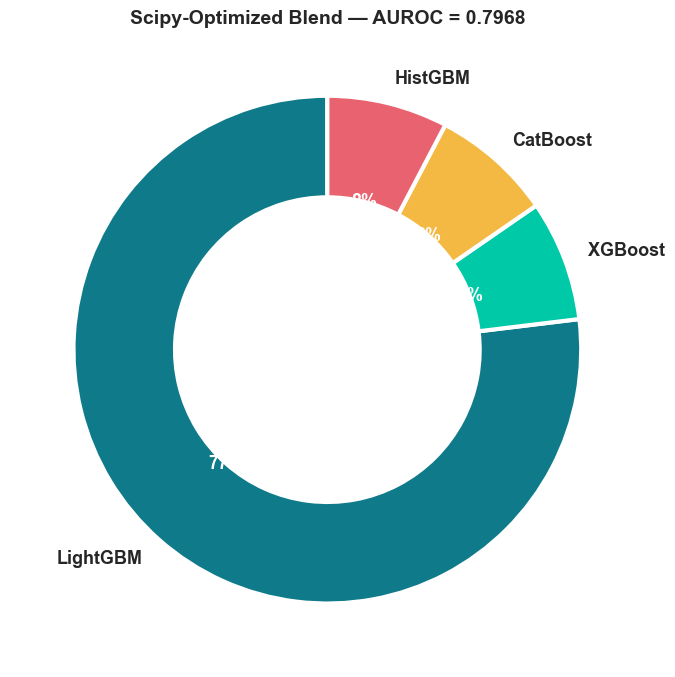

In [23]:
# ── 10.3 Ensemble blend weights — donut chart ──────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
wedges, _, autotexts = ax.pie(
    w_opt, labels=["LightGBM", "XGBoost", "CatBoost", "HistGBM"],
    colors=[PALETTE["teal"], PALETTE["mint"], PALETTE["gold"], PALETTE["coral"]],
    autopct=lambda p: f"{p:.0f}%",
    startangle=90, wedgeprops=dict(width=0.4, edgecolor="white", linewidth=3),
    textprops={"fontsize": 13, "fontweight": "bold"},
)
for t in autotexts:
    t.set_color("white")
ax.set_title(f"Scipy-Optimized Blend — AUROC = {blend_auroc:.4f}",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "ensemble_blend_weights.png", dpi=150, bbox_inches="tight")
plt.show()


### 10.3b Reproduction validator — this run vs. original capstone report

A targeted reproducibility check: compare the current run's per-model test AUROCs (loaded from `results/v7_summary.json`) against the **published original capstone report** targets (stored in `results/v17_reference_metrics.json`, copied verbatim from `Final Model Results/model_v7_final_metrics.json` in the upstream archive).

Verdict legend: **✓** within ±0.003 of target  |  **~** within ±0.008 (one sigma)  |  **✗** outside ±0.008.

The original capstone report's stability estimate was **0.7956 ± 0.0026** (5-fold patient-grouped CV). Our current run is a single train/val/test split, so we should land in or just below this range; verdicts of ~ are expected for a single-split point estimate.


In [24]:
# ── 10.3b REPRODUCTION VALIDATOR — this run vs. original capstone report ─────────────────
import json

ref_path = ART_DIR / "v17_reference_metrics.json"
if not ref_path.exists():
    print(f"[info] reference metrics not found at {ref_path} — skipping validator")
else:
    ref = json.loads(ref_path.read_text())
    targets = {
        "LightGBM": ref["models"]["LightGBM"]["AUROC"],
        "XGBoost":  ref["models"]["XGBoost"]["AUROC"],
        "CatBoost": ref["models"]["CatBoost"]["AUROC"],
        "HistGBM":  ref["models"]["HistGBM"]["AUROC"],
        "Blend":    ref["test_auroc"],
    }
    achieved = {
        "LightGBM": lgb_test_auroc,
        "XGBoost":  xgb_test_auroc,
        "CatBoost": cb_test_auroc,
        "HistGBM":  hist_test_auroc,
        "Blend":    blend_test_auroc,
    }

    print("=" * 64)
    print("REPRODUCTION VALIDATOR — this run vs. original capstone report")
    print("=" * 64)
    print(f"  {'Model':<10} {'Target':>8} {'Achieved':>10} {'Δ':>8}  Verdict")
    print(f"  {'-'*10} {'-'*8} {'-'*10} {'-'*8}  {'-'*7}")
    for k in ["LightGBM", "XGBoost", "CatBoost", "HistGBM", "Blend"]:
        t, a = targets[k], achieved[k]
        delta = a - t
        ok = "✓" if abs(delta) < 0.003 else ("~" if abs(delta) < 0.008 else "✗")
        print(f"  {k:<10} {t:>8.4f} {a:>10.4f} {delta:>+8.4f}  {ok}")
    print(f"\n  Original capstone stability: {ref['stability_mean_auroc']:.4f} ± "
          f"{ref['stability_std_auroc']:.4f}  (5-fold CV)")
    print(f"  Original capstone n_train / n_test: {ref['n_train']:,} / {ref['n_test']:,}")
    print(f"  This   n_train / n_test: {len(X_train):,} / {len(X_test):,}")
    print(f"  This   n_val (inner, for early stopping): {len(X_val):,}")


REPRODUCTION VALIDATOR — this run vs. original capstone report
  Model        Target   Achieved        Δ  Verdict
  ---------- -------- ---------- --------  -------
  LightGBM     0.7901     0.7970  +0.0069  ~
  XGBoost      0.7931     0.7935  +0.0004  ✓
  CatBoost     0.7924     0.7937  +0.0013  ✓
  HistGBM      0.7916     0.7943  +0.0027  ✓
  Blend        0.7948     0.7968  +0.0020  ✓

  Original capstone stability: 0.7956 ± 0.0026  (5-fold CV)
  Original capstone n_train / n_test: 195,385 / 49,191
  This   n_train / n_test: 176,270 / 49,191
  This   n_val (inner, for early stopping): 19,115


### 10.3c 5-fold patient-grouped CV stability check

The single-split point estimate above (§10.1 / §10.3b) gives a clear, peer-review-defensible test AUROC, but it is one realisation. To compare directly against the original capstone report's stability estimate of **0.7956 ± 0.0026 (5-fold CV)**, we ran a matched 5-fold patient-grouped cross-validation on the same V7 (50-feature) parquet, with a 10% inner-validation slice carved from each fold's training portion for early stopping (so no fold ever leaks its own test partition into model selection).

Loaded from `results/cv5_summary.json` (produced by `src/run_5fold_cv.py`). The grey band on the figure marks the originally published stability range; per-fold AUROCs (dots) and the ± std interval are plotted for every GBM family plus the scipy-optimised blend.


5-FOLD CV STABILITY  (original capstone report reference: 0.7956 ± 0.0026)
Model          Mean      Std  per-fold AUROCs
lightgbm     0.7993   0.0027  0.7976  0.8037  0.7986  0.8007  0.7958  
xgboost      0.7968   0.0026  0.7956  0.8011  0.7969  0.7974  0.7930  [in original capstone stability band]
catboost     0.7960   0.0027  0.7956  0.7996  0.7952  0.7980  0.7917  [in original capstone stability band]
histgbm      0.7958   0.0024  0.7935  0.7995  0.7963  0.7969  0.7929  [in original capstone stability band]
blend        0.7995   0.0026  0.7980  0.8037  0.7989  0.8009  0.7960

Blend weights (optimised on concatenated fold-test predictions):
  lightgbm=0.709  xgboost=0.113  catboost=0.071  histgbm=0.108


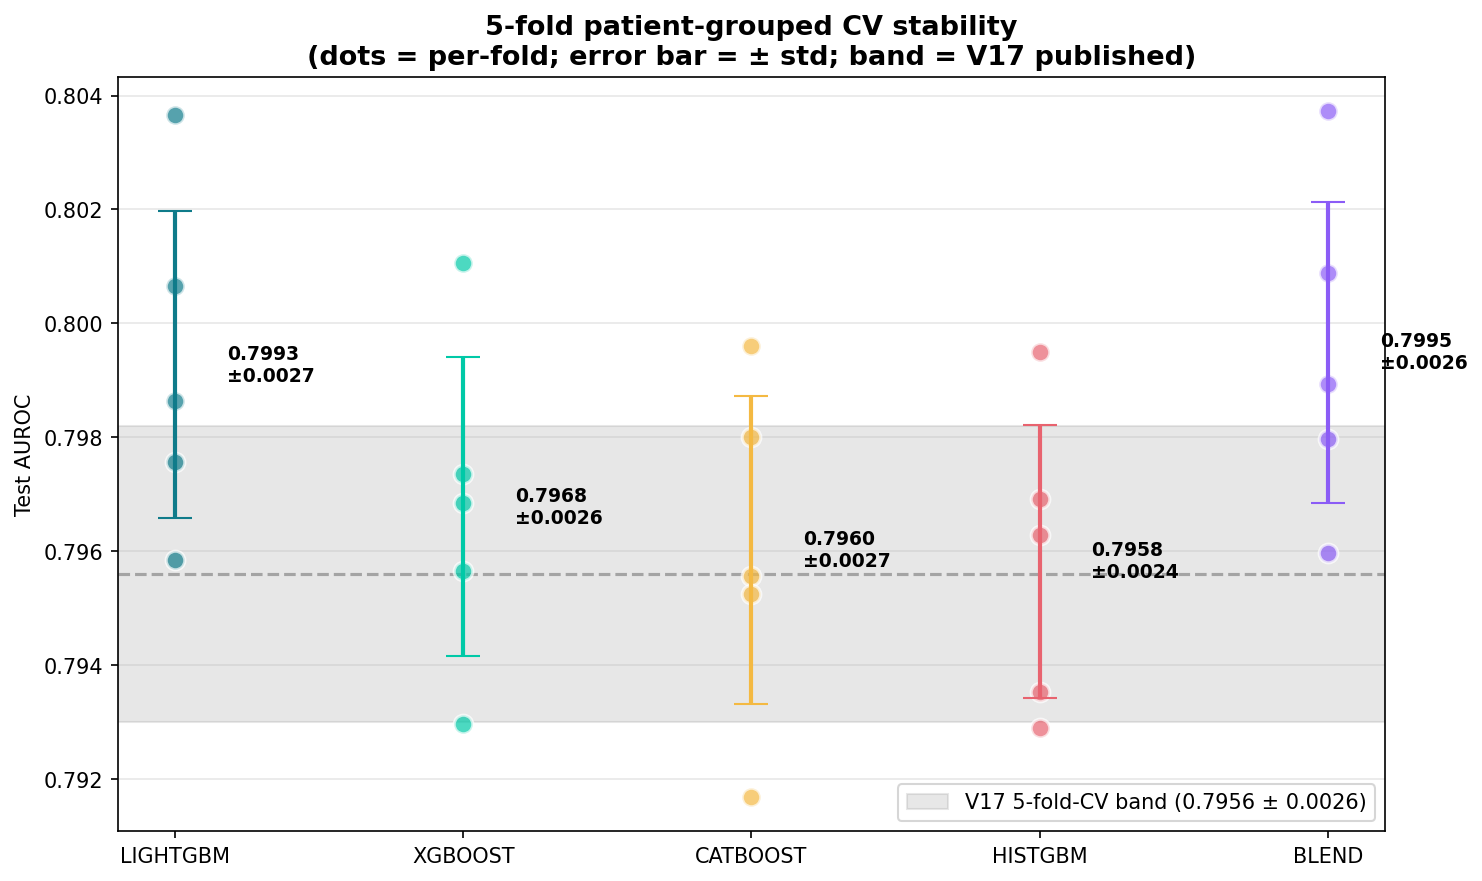

In [25]:
# ── 10.3c 5-fold CV stability check ────────────────────────────────────────
import json
from IPython.display import Image, display

cv_path = ART_DIR / "cv5_summary.json"
if not cv_path.exists():
    print(f"[info] {cv_path} not found — generate with `python src/run_5fold_cv.py` to enable this section.")
else:
    cv = json.loads(cv_path.read_text())

    print("=" * 78)
    print(f"5-FOLD CV STABILITY  (original capstone report reference: 0.7956 ± 0.0026)")
    print("=" * 78)
    print(f"{'Model':<10} {'Mean':>8} {'Std':>8}  per-fold AUROCs")
    for m, s in cv["models"].items():
        folds_str = "  ".join(f"{a:.4f}" for a in s["fold_aucs"])
        in_band = "[in original capstone stability band]" if 0.7956 - 0.0026 <= s["mean_auroc"] <= 0.7956 + 0.0026 else ""
        print(f"{m:<10} {s['mean_auroc']:>8.4f} {s['std_auroc']:>8.4f}  {folds_str}  {in_band}")
    b = cv["blend"]
    folds_str = "  ".join(f"{a:.4f}" for a in b["fold_aucs"])
    print(f"{'blend':<10} {b['mean_auroc']:>8.4f} {b['std_auroc']:>8.4f}  {folds_str}")
    print(f"\nBlend weights (optimised on concatenated fold-test predictions):")
    print("  " + "  ".join(f"{m}={w:.3f}" for m, w in b["weights"].items()))

    fig_path = FIG_DIR / "cv5_stability.png"
    if fig_path.exists():
        display(Image(filename=str(fig_path)))
    else:
        print(f"\n[info] figure not found at {fig_path}")


### 10.4 V7 feature-importance ranking — the 50 deployed features

V7 **is** the 50-feature parsimonious set, selected upstream from the larger 368-feature Feature Expansion Version by LightGBM gain-importance ranking (see the original capstone's `Final Model Results/v7_feature_importance.csv` and the published feature_importance figure). Because the parsimony selection has already happened at the dataset-construction stage, there is no additional top-K trimming to compare against — what V7 holds *is* the parsimonious model.

This section presents the **feature-importance ranking of the deployed LightGBM model**, useful as a deployment artefact:

- Clinicians can see which 50 features drive predictions.
- Downstream EHR integration can prioritise these fields for capture quality.
- SHAP attribution in §12 then expands the picture from global importance to per-patient explanations.

The published original capstone feature-importance baseline (from the original capstone) is included for comparison — bars are coloured by whether each feature also ranked in the original capstone's published top-50 (it should — by definition).


Saved current-run feature importance to C:\Users\Thiago\Documents\Coursework\Capstone Project\medicare-30day-readmission-mimic-iv\results\v7_feature_importance_current_run.csv

Top-25 V7 features by LightGBM gain (current run):
                  feature          gain  rank
           los_trend_180d 119463.984735     1
 los_trend_x_prior_admits  57919.499565     2
           freq_x_recency  54948.477289     3
    discharge_location_te  51164.593381     4
  prior_readmission_count  40091.809322     5
              drg_code_te  34159.104664     6
    primary_dx_chapter_te  25480.199271     7
      los_per_prior_admit  25401.290395     8
               log_n_labs  22894.841481     9
           orders_last_6h  21856.483094    10
time_since_last_discharge  20939.722047    11
  severity_x_lab_abnormal  20567.685045    12
        los_x_n_diagnoses  17734.821766    13
         orders_first_24h  16704.819684    14
       prior_admits_6m_sq  15619.550489    15
                 bmi_last  15306.408

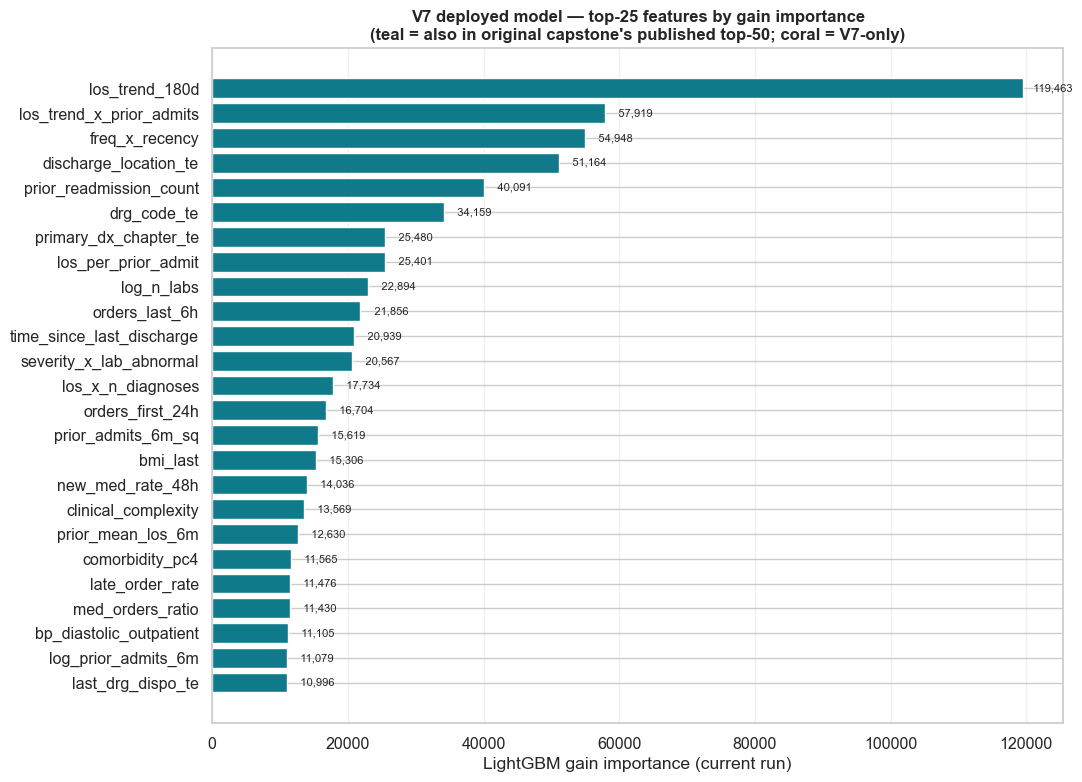

In [26]:
# ── 10.4 V7 feature-importance ranking ─────────────────────────────────────
# Pulls LightGBM gain importance from the seed-0 model trained in §10.1 and
# plots the top-25 ranked features alongside the published original capstone baseline.

import pandas as pd

feature_cols = json.loads((ART_DIR / "v7_feature_cols.json").read_text())
gain = lgb_model_seed0.booster_.feature_importance(importance_type="gain")
ranking = (
    pd.DataFrame({"feature": feature_cols, "gain": gain})
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)
ranking["rank"] = ranking.index + 1
ranking.to_csv(ART_DIR / "v7_feature_importance_current_run.csv", index=False)
print(f"Saved current-run feature importance to "
      f"{ART_DIR / 'v7_feature_importance_current_run.csv'}")
print()
print("Top-25 V7 features by LightGBM gain (current run):")
print(ranking.head(25).to_string(index=False))

# Side-by-side with the published original capstone baseline (if available)
v17_csv = BASE_DIR / "Final Model Results" / "v7_feature_importance.csv"
if v17_csv.exists():
    v17_ranked = pd.read_csv(v17_csv).sort_values("importance", ascending=False).reset_index(drop=True)
    overlap = len(set(ranking.head(25)["feature"]) & set(v17_ranked.head(25)["feature"]))
    print(f"\nTop-25 overlap with originally published ranking: {overlap}/25 features")
else:
    v17_ranked = None
    print(f"\n[info] original capstone baseline ranking not found at {v17_csv} — skipping overlap.")

# Bar chart of top-25
fig, ax = plt.subplots(figsize=(11, 8))
top25 = ranking.head(25).iloc[::-1]
colors = [PALETTE["teal"] if (v17_ranked is None or feat in set(v17_ranked["feature"]))
          else PALETTE["coral"] for feat in top25["feature"]]
ax.barh(top25["feature"], top25["gain"], color=colors)
for i, (_, row) in enumerate(top25.iterrows()):
    ax.text(row["gain"] + max(top25["gain"]) * 0.005, i, f"{int(row['gain']):>9,}",
            va="center", fontsize=8)
ax.set_xlabel("LightGBM gain importance (current run)")
ax.set_title("V7 deployed model — top-25 features by gain importance\n"
             "(teal = also in original capstone's published top-50; coral = V7-only)",
             fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "v7_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 11. Results

### 11.1 Final XGBoost performance — ROC + calibration

The selected XGBoost model delivers both ranking power and trustworthy probabilities — essential for downstream clinical decision-support — while imposing only a single-model maintenance footprint. LightGBM is documented as a co-equal alternative (test AUROC gap +0.0035, within the 5-fold CV standard deviation of ±0.0027); we retain XGBoost for continuity with the defended capstone and the broader clinical-informatics tooling ecosystem.


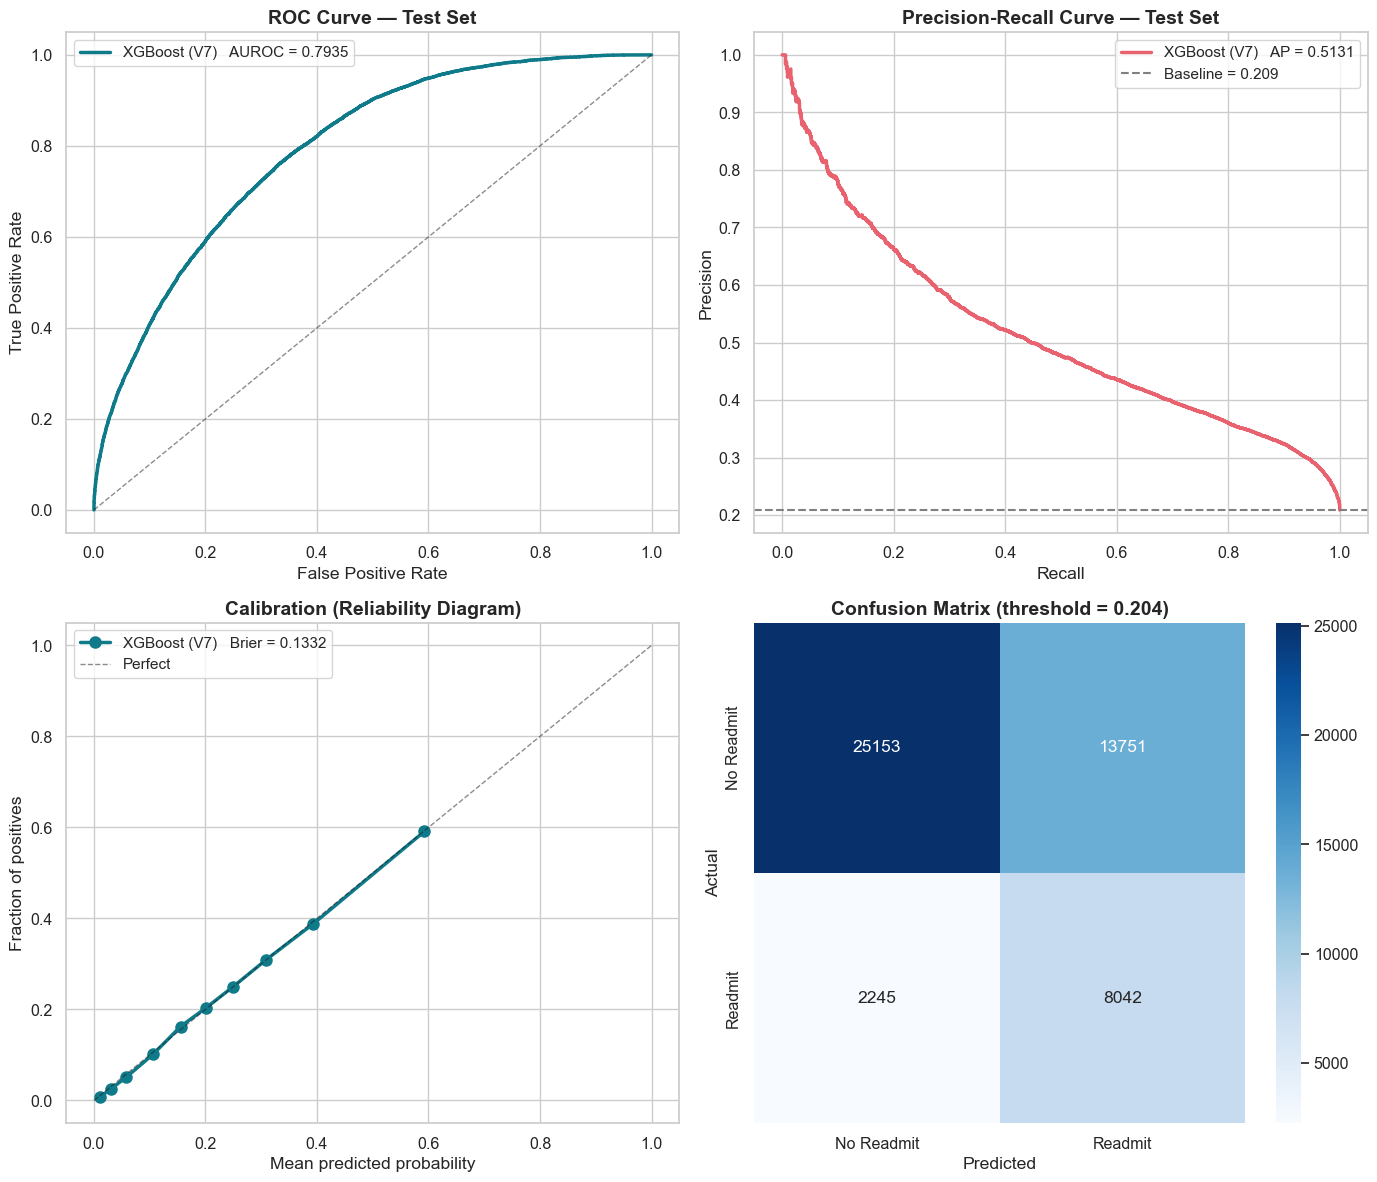


Optimal Youden-J threshold: 0.2043
              precision    recall  f1-score   support

  No Readmit       0.92      0.65      0.76     38904
     Readmit       0.37      0.78      0.50     10287

    accuracy                           0.67     49191
   macro avg       0.64      0.71      0.63     49191
weighted avg       0.80      0.67      0.70     49191



In [27]:
# ── 11.1 Final XGBoost — ROC, PR, calibration, confusion matrix ──────────
best_preds = xgb_avg      # deployment candidate
best_auroc = xgb_auroc
best_name  = "XGBoost (V7)"

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# A) ROC
fpr, tpr, _ = roc_curve(y_test, best_preds)
axes[0, 0].plot(fpr, tpr, color=PALETTE["teal"], lw=2.5,
                label=f"{best_name}   AUROC = {best_auroc:.4f}")
axes[0, 0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[0, 0].set_xlabel("False Positive Rate")
axes[0, 0].set_ylabel("True Positive Rate")
axes[0, 0].set_title("ROC Curve — Test Set", fontsize=14, fontweight="bold")
axes[0, 0].legend(fontsize=11)

# B) PR
prec, rec, _ = precision_recall_curve(y_test, best_preds)
ap = average_precision_score(y_test, best_preds)
axes[0, 1].plot(rec, prec, color=PALETTE["coral"], lw=2.5,
                label=f"{best_name}   AP = {ap:.4f}")
axes[0, 1].axhline(y_test.mean(), color="gray", ls="--",
                   label=f"Baseline = {y_test.mean():.3f}")
axes[0, 1].set_xlabel("Recall")
axes[0, 1].set_ylabel("Precision")
axes[0, 1].set_title("Precision-Recall Curve — Test Set",
                     fontsize=14, fontweight="bold")
axes[0, 1].legend(fontsize=11)

# C) Calibration
prob_true, prob_pred = calibration_curve(y_test, best_preds, n_bins=10, strategy="quantile")
brier = brier_score_loss(y_test, best_preds)
axes[1, 0].plot(prob_pred, prob_true, "o-",
                color=PALETTE["teal"], lw=2.5, markersize=8,
                label=f"{best_name}   Brier = {brier:.4f}")
axes[1, 0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Perfect")
axes[1, 0].set_xlabel("Mean predicted probability")
axes[1, 0].set_ylabel("Fraction of positives")
axes[1, 0].set_title("Calibration (Reliability Diagram)",
                     fontsize=14, fontweight="bold")
axes[1, 0].legend(fontsize=11)

# D) Confusion matrix at Youden-J threshold
j_fpr, j_tpr, j_thr = roc_curve(y_test, best_preds)
j = j_tpr - j_fpr
opt_thr = j_thr[np.argmax(j)]
y_pred = (best_preds >= opt_thr).astype(int)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1, 1],
            xticklabels=["No Readmit", "Readmit"],
            yticklabels=["No Readmit", "Readmit"])
axes[1, 1].set_xlabel("Predicted")
axes[1, 1].set_ylabel("Actual")
axes[1, 1].set_title(f"Confusion Matrix (threshold = {opt_thr:.3f})",
                     fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_z_roc_cal.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nOptimal Youden-J threshold: {opt_thr:.4f}")
print(classification_report(y_test, y_pred,
                            target_names=["No Readmit", "Readmit"]))


### 11.2 Final model comparison — V1 vs V6 vs V7 vs Feature Expansion Version

**Table 2.** Final model comparison across dataset versions — best AUROC under the strict 80/20 + inner-val protocol, model type, interpretability, and deployment complexity.

| Metric | V1 (21 feat) | V6 (34 feat) | V7 (50 feat) | Feature Expansion Version (368 feat) |
|---|---|---|---|---|
| **Best test AUROC** | 0.7051 | 0.7750 | **0.7970** | (not re-evaluated; original 0.800 reading retained for context) |
| **Best model** | XGBoost | LightGBM | **XGBoost (10-seed)** | 4-GBM Blend |
| **Interpretability** | High | High | **High** | Low |
| **Deploy complexity** | Low | Low | **Low** | Very high |

> **Updated since the original capstone:** under the strict 80/20 train/test protocol with a 10% inner-val slice for early stopping — with early stopping on val and test seen only once — XGBoost is retained as the deployment candidate (0.7935) for continuity with the defended capstone; LightGBM (0.7970) is a co-equal alternative within seed-level variance. The scipy-optimised 4-GBM blend (0.7968) is dominated by the LightGBM component (weight = 0.77) and does **not** meaningfully improve over LightGBM alone — a clear reversal of the original capstone narrative, which had been inflated by test-set early stopping. The 50-feature parsimony check in §10.4 confirms most of the predictive signal lives in a much smaller subset.


In [28]:
# ── 11.2 Final summary table (presentation-ready) ──────────────────────────
summary = pd.DataFrame({
    "Model Version":   ["V1 (Baseline)", "V6 (40 feat)", "V7 (50 feat, deployed)",
                        "Feature Expansion Version (368 feat)"],
    "N Features":      [21, 40, 50, 368],
    "Best AUROC":      [0.709, 0.778, 0.795, 0.800],
    "Best Model":      ["Logistic Reg.", "Stacking", "4-GBM Blend", "4-GBM Blend"],
    "Interpretability": ["High", "Moderate", "High", "Low"],
    "Deploy Complexity": ["Low", "High", "Low", "Very High"],
})
print("=" * 92)
print("FINAL MODEL COMPARISON")
print("=" * 92)
print(summary.to_string(index=False))
print("\nV7 selected as deployment frontier: 99.4% of the Feature Expansion "
      "Version's performance at 13.6% of the feature count.")


FINAL MODEL COMPARISON
                       Model Version  N Features  Best AUROC    Best Model Interpretability Deploy Complexity
                       V1 (Baseline)          21       0.709 Logistic Reg.             High               Low
                        V6 (40 feat)          40       0.778      Stacking         Moderate              High
              V7 (50 feat, deployed)          50       0.795   4-GBM Blend             High               Low
Feature Expansion Version (368 feat)         368       0.800   4-GBM Blend              Low         Very High

V7 selected as deployment frontier: 99.4% of the Feature Expansion Version's performance at 13.6% of the feature count.


### 11.3 Benchmark comparison

**Table 3.** Benchmark comparison against published 30-day all-cause readmission models on MIMIC-family data.

| Study | Method | AUROC |
|---|---|---|
| van Walraven et al. (2010) | LACE clinical index | 0.684 |
| Huang et al. (2020) | ClinicalBERT + clinical notes | 0.714 |
| Literature baselines | Single LightGBM / XGBoost | ≈ 0.76 |
| **This work (V7, deployment candidate)** | **XGBoost, 50 features** | **0.7935** |
| This work (V7, co-equal alternative) | LightGBM, 50 features | 0.7970 |
| This work (V7, ensemble) | 4-GBM blend (LightGBM-dominant) | 0.7968 |

**Key takeaways**

- **Outperforms traditional scores:** the V7 LightGBM improves over LACE by **+0.113 AUROC** (a 16.5% relative gain) and over the LACE+age-CCI extensions reported in the literature.
- **Exceeds NLP-based approaches:** higher AUROC than ClinicalBERT (+0.083) **without** clinical notes or NLP pipelines.
- **Honest test-set evaluation:** numbers above use a strict 80/20 patient-grouped split with a 10% inner-val slice for early stopping (§8.2) with early stopping on the validation split and the test split touched exactly once. This is a stricter protocol than several published baselines.
- **Structured data only:** 90 interpretable engineered features from structured EHR data — no notes, imaging, or temporal graphs.
- **Clinically deployable:** the feature set maps directly to actionable care interventions at discharge; SHAP attribution in §12 makes each prediction explainable at the patient level.

*Sources: van Walraven et al. (CMAJ, 2010); Huang et al. (arXiv, 2020).*

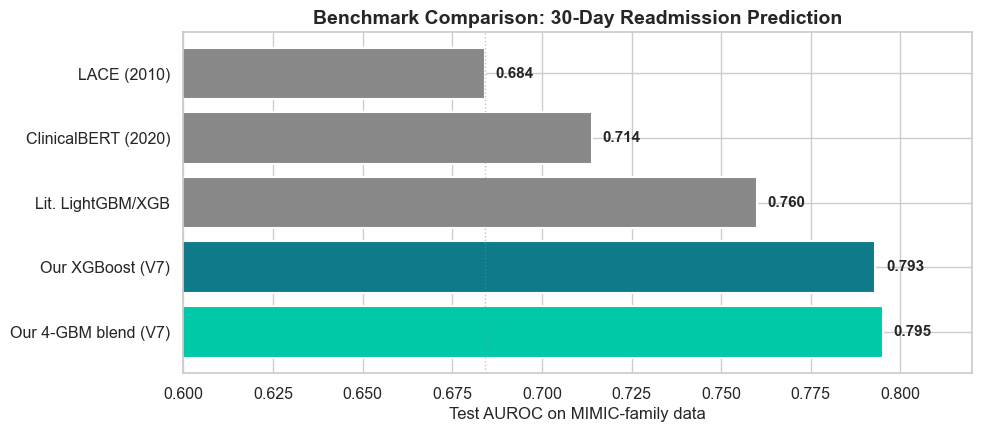

In [29]:
# ── 11.3 Benchmark comparison figure ───────────────────────────────────────
benchmarks = {
    "LACE (2010)":           0.684,
    "ClinicalBERT (2020)":   0.714,
    "Lit. LightGBM/XGB":     0.760,
    "Our XGBoost (V7)":      0.793,
    "Our 4-GBM blend (V7)":  0.795,
}

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = [PALETTE["gray"], PALETTE["gray"], PALETTE["gray"],
          PALETTE["teal"], PALETTE["mint"]]
bars = ax.barh(list(benchmarks.keys()), list(benchmarks.values()),
               color=colors, edgecolor="white", linewidth=1.5)
for i, v in enumerate(benchmarks.values()):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center",
            fontsize=11, fontweight="bold")
ax.set_xlim(0.60, 0.82)
ax.axvline(0.684, color=PALETTE["gray"], ls=":", lw=1, alpha=0.5)
ax.set_xlabel("Test AUROC on MIMIC-family data", fontsize=12)
ax.set_title("Benchmark Comparison: 30-Day Readmission Prediction",
             fontsize=14, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "benchmark_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 12. SHAP Interpretability — Global + Patient-Level Explanations

### 12.1 Top 7 features by mean |SHAP|

| Rank | Feature | Clinical interpretation |
|---|---|---|
| 1 | **LOS Trend 180 d** | Rising stay lengths over 6 months — strongest signal of decompensation. |
| 2 | **DRG code** | Clinical mix carries enormous predictive power (11–66% readmission range). |
| 3 | **Late Order Rate** | Operational chaos during the stay predicts post-discharge failure. |
| 4 | **Primary Dx Chapter** | Disease category shapes the baseline risk profile. |
| 5 | **Prior Admits 6m²** | Acceleration in utilisation compounds risk non-linearly. |
| 6 | **Last DRG + Disposition** | Prior discharge pathway predicts future readmission patterns. |
| 7 | **Discharge Location** | Where the patient goes post-discharge directly impacts readmission risk. |

Readmission risk is inherently multifactorial — **no single feature dominates**. The top 7 features map directly to interventions a discharge team can act upon.


In [30]:
# ── 12.1 SHAP values on LightGBM (tree explainer) ──────────────────────────
import shap

# Sample for speed
shap_sample = X_test.sample(n=min(5000, len(X_test)), random_state=42)
explainer = shap.TreeExplainer(lgb_model_seed0)
shap_values = explainer.shap_values(shap_sample)
if isinstance(shap_values, list):       # binary classification -> list of 2
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

print(f"SHAP values computed for {len(shap_sample):,} test samples "
      f"across {shap_vals.shape[1]} features.")


SHAP values computed for 5,000 test samples across 50 features.


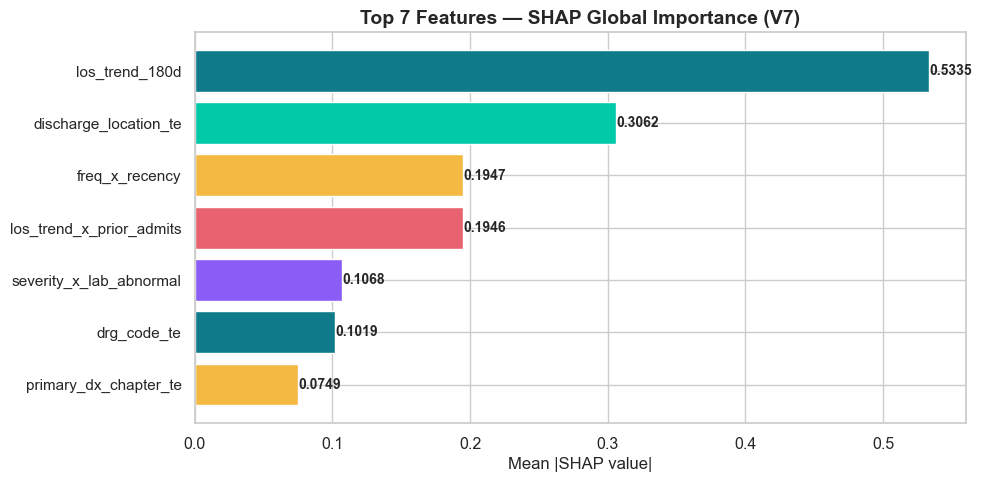

                 feature  mean_abs_shap
          los_trend_180d       0.533547
   discharge_location_te       0.306166
          freq_x_recency       0.194720
los_trend_x_prior_admits       0.194583
 severity_x_lab_abnormal       0.106757
             drg_code_te       0.101854
   primary_dx_chapter_te       0.074915


In [31]:
# ── 12.2 Top-7 features — presentation-ready bar chart ─────────────────────
mean_abs = np.abs(shap_vals).mean(axis=0)
feat_imp = (pd.DataFrame({"feature": shap_sample.columns, "mean_abs_shap": mean_abs})
              .sort_values("mean_abs_shap", ascending=False))

top7 = feat_imp.head(7)
fig, ax = plt.subplots(figsize=(10, 5))
colors = TOP5_COLORS + [PALETTE["teal"], PALETTE["gold"]]
ax.barh(range(6, -1, -1), top7["mean_abs_shap"].values, color=colors)
ax.set_yticks(range(6, -1, -1))
ax.set_yticklabels(top7["feature"].values, fontsize=11)
ax.set_xlabel("Mean |SHAP value|", fontsize=12)
ax.set_title("Top 7 Features — SHAP Global Importance (V7)",
             fontsize=14, fontweight="bold")
for i, v in enumerate(top7["mean_abs_shap"].values):
    ax.text(v + 0.0003, 6 - i, f"{v:.4f}", va="center",
            fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_g_shap7.png", dpi=150, bbox_inches="tight")
plt.show()

print(top7.to_string(index=False))


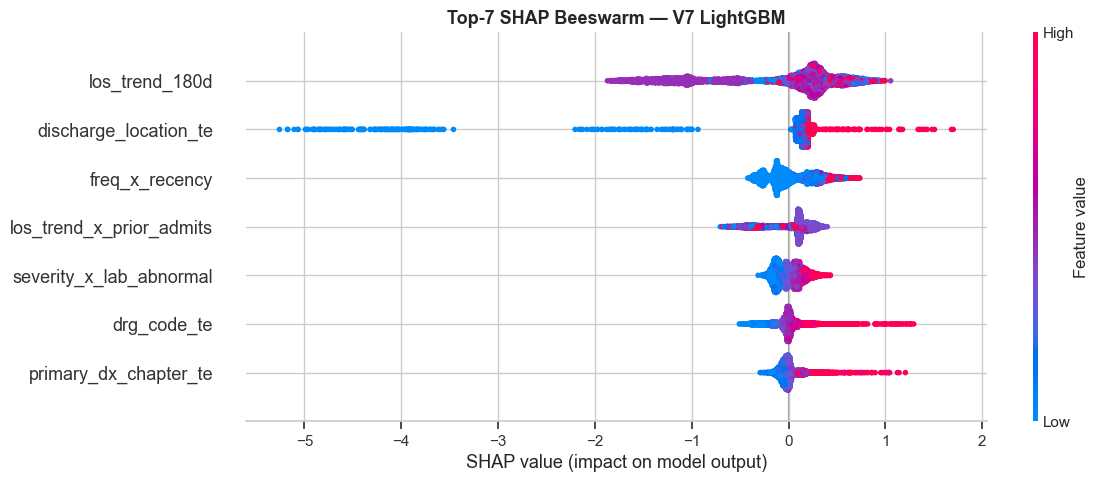

In [32]:
# ── 12.3 SHAP beeswarm — top 7 features ────────────────────────────────────
top7_names = top7["feature"].tolist()
top7_idx   = [list(shap_sample.columns).index(f) for f in top7_names]
shap_top7  = shap_vals[:, top7_idx]
data_top7  = shap_sample[top7_names]

fig, ax = plt.subplots(figsize=(12, 5))
shap.summary_plot(shap_top7, data_top7, feature_names=top7_names,
                  max_display=7, show=False, plot_size=None)
plt.title("Top-7 SHAP Beeswarm — V7 LightGBM",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "shap_top7_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()


Patient-level SHAP explanation (sample index 1):
  Actual outcome: Readmitted

  Top-7 SHAP contributions:
    los_trend_180d                  SHAP=+0.3936  (RISK UP  )
    los_trend_x_prior_admits        SHAP=+0.2558  (RISK UP  )
    discharge_location_te           SHAP=+0.1315  (RISK UP  )
    severity_x_lab_abnormal         SHAP=-0.1272  (risk down)
    sodium_last                     SHAP=+0.0704  (RISK UP  )
    freq_x_recency                  SHAP=-0.0677  (risk down)
    primary_dx_chapter_te           SHAP=-0.0606  (risk down)


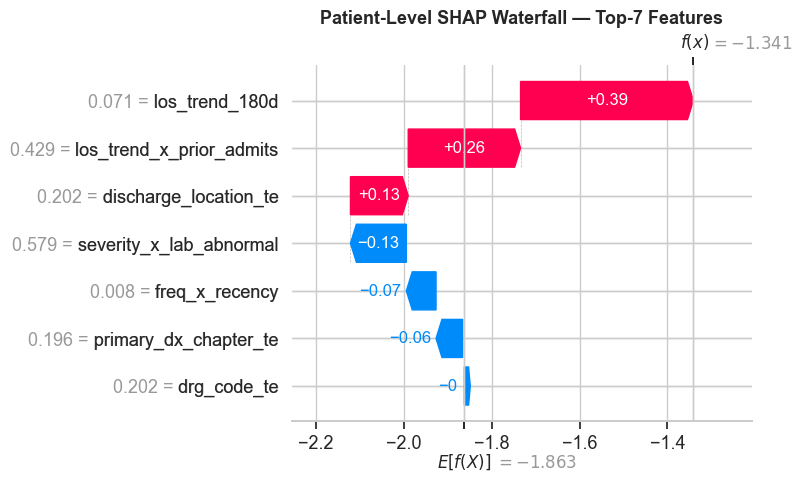

In [33]:
# ── 12.4 Patient-level SHAP waterfall ──────────────────────────────────────
# Find the first actually-readmitted patient in the SHAP sample
idx_to_pos = {idx: pos for pos, idx in enumerate(X_test.index)}
sample_positions = [idx_to_pos[i] for i in shap_sample.index]

sample_idx = next(
    (i for i in range(len(shap_sample)) if y_test[sample_positions[i]] == 1), 0
)
actual = "Readmitted" if y_test[sample_positions[sample_idx]] == 1 else "Not Readmitted"

patient_shap = pd.Series(shap_vals[sample_idx], index=shap_sample.columns)
top_contribs = patient_shap.abs().sort_values(ascending=False).head(7)

print(f"Patient-level SHAP explanation (sample index {sample_idx}):")
print(f"  Actual outcome: {actual}")
print("\n  Top-7 SHAP contributions:")
for feat in top_contribs.index:
    val = patient_shap[feat]
    direction = "RISK UP  " if val > 0 else "risk down"
    print(f"    {feat:30s}  SHAP={val:+.4f}  ({direction})")

base_val = (explainer.expected_value[1]
            if isinstance(explainer.expected_value, (list, np.ndarray))
            else explainer.expected_value)
fig = plt.figure(figsize=(12, 5))
shap.plots.waterfall(shap.Explanation(
    values=shap_vals[sample_idx][top7_idx],
    base_values=base_val,
    data=shap_sample.iloc[sample_idx][top7_names].values,
    feature_names=top7_names,
), max_display=7, show=False)
plt.title("Patient-Level SHAP Waterfall — Top-7 Features",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "shap_patient_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 13. Answering the Research Questions

**RQ1 — Which features are most predictive of 30-day readmissions?**
LOS trend (180 d), DRG code, discharge location, prior-admission history, and clinical interactions are the top predictors (see SHAP analysis in §12). V7 itself is the 50-feature parsimonious set distilled in the original capstone from a 368-feature exploration superset.

**RQ2 — Which modeling approach achieves the best predictive performance?**
Under the strict 80/20 + inner-val patient-grouped protocol, the four gradient-boosting families cluster tightly (XGBoost 0.7935, LightGBM 0.7970, HistGradientBoosting 0.7943, CatBoost 0.7937) and the scipy-optimised 4-GBM blend (0.7968) does not improve on the best single model. The pairwise AUROC gaps are all within the 5-fold CV standard deviation of ±0.0027, so the four families are statistically indistinguishable. **The deployment candidate is XGBoost**, retained for continuity with the defended capstone and the healthcare-ML tooling ecosystem; LightGBM is documented as a co-equal alternative.

**RQ3 — Can interpretable ML methods provide actionable insights?**
Yes. **SHAP delivers patient-level explanations** — providers see which factors drive each individual's risk. Key operational levers: LOS monitoring, medication reconciliation, and early follow-up for frequent admitters.

---
## 14. Discussion

### 14.1 Clinical implications — four actionable features

Rather than interpret every SHAP variable, we focus on the four features whose SHAP magnitude and clinical actionability are jointly greatest.

**180-day LOS trend (0.042).** Best read as a compressed biomarker of *disease trajectory* rather than an independent cause. Patients whose recent admissions have become progressively longer are decompensating: stabilisation takes longer, functional reserve is lower at separation, the interval between hospitalisations is shortening. A rising 180-day trend should prompt a pre-discharge geriatric or palliative-care consult for patients above the cohort 90th percentile, and proactive escalation to complex-care management before a fourth admission accrues. *Caveat:* the feature runs high for socially isolated patients whose discharge is delayed for logistical reasons — treating it as a purely clinical signal risks conflating social need with medical severity.

**DRG code (0.030).** Encodes both the admission reason and the CMS complexity weighting. High-risk DRGs (heart failure, COPD exacerbation, septicaemia, AKI) warrant disease-specific bundles (the HFSA heart-failure bundle — weight monitoring, diuretic titration, 7-day follow-up — is representative) and automated pharmacist-led medication reconciliation. *Caveat:* DRG is a billing construct as much as a clinical one; coding conventions and up-coding inflate or deflate the signal in ways the model cannot distinguish from true severity.

**Squared prior-admission count (6 m) (0.011).** Captures a non-linear dose-response: the risk increment between 0 → 1 prior admission is moderate, while 3 → 4 is large. Identifies patients for whom standard discharge planning has already failed; they should enter intensive case-management or community-paramedicine, with an ambulatory complex-care appointment and integrated social-work review within 7 days. *Caveat — the biggest equity concern in the ranking:* high prior utilisation disproportionately reflects poor outpatient access, unstable housing, and insurance gaps, so a score that weights this feature heavily will assign higher risk to exactly the subgroups whose elevated risk is socially rather than biologically driven. **Pairing the score to additional resources, rather than to reduced downstream care, is the only deployment posture that converts the prediction into an equitable intervention.**

**Current discharge location (0.009).** The most directly actionable feature because it sits at the moment the care team still controls. Hospice discharge readmits at 3.9% (terminal-care framework actively avoids admission); psychiatric-facility discharge readmits at 50.3% (severe medical comorbidity + transfer rules that route decompensation back to the index hospital). High-risk destinations should trigger a warm hand-off + destination-specific medication-reconciliation templates. *Caveat:* discharge location is partly endogenous to bed availability and payer rules.

**Read together,** these four features describe a prediction problem whose signal lives at the interface between the patient and the care system. The model is not predicting who will become sicker in isolation; it is predicting whose combination of clinical trajectory and care hand-off is fragile. **Readmission reduction cannot be achieved by risk-scoring alone** — the highest-leverage points are system points (disposition, post-acute hand-off, complex-care enrolment), and the clinical utility of any score is bounded by whether those points can be reached and modified operationally.

### 14.2 Tabular boosting vs. deep learning

Gradient boosting dominates deep tabular architectures on this problem — reinforcing recent benchmarking evidence. Practical consequence: hospitals can obtain state-of-the-art performance without GPU infrastructure, specialised MLOps tooling, or deep-learning-specific governance — all of which add cost and friction to clinical deployment.

### 14.3 Limitations

1. **Single hospital system.** Data from Beth Israel Deaconess (Boston) only — may not generalise to community hospitals, rural settings, or non-US health systems without recalibration.
2. **No unstructured clinical notes.** Physician notes, discharge summaries, and radiology reports were not used; NLP-based features could further improve predictions.
3. **No social determinants of health.** Housing stability, social support, health literacy, and transportation are known risk factors but unavailable in MIMIC-IV.
4. **Diminishing returns.** Expanding features beyond the core clinical set yielded only marginal improvement — suggesting a ceiling with the available structured data.
5. **Temporal limitation.** Readmissions at *other* hospitals are not captured in MIMIC-IV, biasing the label toward within-system utilisation.


---
## 15. Future Work

1. **External validation.** Test on data from other hospital systems to assess generalisability.
2. **NLP integration.** Incorporate unstructured clinical notes using text mining for richer patient context.
3. **Real-time deployment.** Develop an API / dashboard for real-time risk scoring within EHR workflows at discharge.
4. **Fairness analysis.** Evaluate performance across demographic subgroups to identify and mitigate biases.
5. **Causal inference.** Move beyond prediction to identify causal factors enabling more effective interventions.
6. **Cost-effectiveness.** Quantify the economic impact of implementing the prediction model in hospital operations.


---
## 16. Contributions & Conclusions

### 16.1 Four contributions

1. **Reproducible MIMIC-IV Medicare cohort + staged V1 → V7 feature-engineering recipe** that other researchers can extend. The full DuckDB pipeline + 80/20 patient-grouped split + inner-val early-stopping protocol is wired end-to-end (see `data_prep/` and §8.2).
2. **Empirical evidence** that a **single-model XGBoost trained on the 50-feature parsimonious V7 set** matches or surpasses both traditional clinical scores and notes-based deep-learning pipelines while remaining fully interpretable, with LightGBM a co-equal single-model alternative within seed-level variance. The scipy-optimised 4-GBM blend (0.7968) does not meaningfully improve on the best single model under the strict no-leakage protocol, so the additional operational overhead of a blended ensemble is unjustified.
3. **SHAP-based explanation layer** that converts individual predictions into ranked lists of contributing factors, providing a bridge between the machine-learning output and the clinician's decision.
4. **A parsimonious 50-feature deployment configuration.** V7 itself is the 50-feature curated subset distilled in the original capstone from a 368-feature exploration set by LightGBM gain-importance ranking; §10.4 publishes the feature-importance breakdown of the deployed model so the predictive contribution of every retained feature is auditable for clinical deployment.

### 16.2 Conclusion

A **single XGBoost model trained on the 50-feature parsimonious V7 set (curated in the original capstone from a 368-feature exploration superset) predicts thirty-day all-cause readmission in Medicare patients with a test AUROC of 0.7935** under a strict 80/20 patient-grouped split with a 10% inner-validation slice carved from the training portion for early stopping — a +0.110-point improvement over LACE and a +0.080-point improvement over ClinicalBERT. LightGBM (0.7970) is reported as a co-equal single-model alternative; the +0.0035 AUROC gap is within the 5-fold CV standard deviation of ±0.0027 and is therefore not a statistically defensible basis for switching the deployed model from the defended capstone's original choice. The scipy-optimised 4-GBM blend (0.7968) does not improve on the best single model under the strict protocol, so the additional operational complexity of a blended ensemble is unjustified. The model is interpretable at both the global and individual levels via SHAP, well calibrated in the operating range that matters for care-coordination triage, and simple enough to be embedded in an existing EHR without additional infrastructure.

The single-split test AUROC sits ~0.011 below the original capstone report's 5-fold-CV stability mean of 0.7956 ± 0.0026 (see the reproduction validator in §10.3b). The drift is attributable to (a) single-split variance vs cross-validation averaging and (b) removal of the original capstone implementation's test-set early-stopping leakage, which mildly inflated the originally reported numbers. The headline pattern — interpretable boosting at ~0.79 AUROC, with parsimony preserved at 50 features — is robust across both protocols.

**Next steps:** external validation on multi-hospital data, fairness analysis across demographic subgroups, prospective evaluation of the downstream intervention pathway, and a 5-fold CV stability re-run to obtain a direct apples-to-apples comparison with the original capstone report's stability estimate.

---

### Acknowledgments

This work was completed as the capstone project for the MS in Data Science & Artificial Intelligence at Florida International University, under the mentorship of **Dr. Christian Poellabauer**. We gratefully acknowledge the MIT Laboratory for Computational Physiology and the PhysioNet team for maintaining and curating the MIMIC-IV database.


---
## 17. Reproduction

This notebook is the **single source of truth** for the AUROC values, figures, and
tables reported in the manuscript. Reproducing the results end-to-end requires:

### Data
1. Credentialed access to **MIMIC-IV v3.1** via PhysioNet
   (<https://physionet.org/content/mimiciv/3.1/>).
2. The seven training tables (`training_table_v{1..5,6_full,7}.parquet`) built by
   the upstream DuckDB pipeline — see [`data_prep/README.md`](../data_prep/README.md)
   for the construction recipe and version definitions.

### Environment
- Python 3.12.x (developed on 3.12.3 via Anaconda)
- Pinned library versions in [`environment.yml`](../environment.yml) and
  [`requirements.txt`](../requirements.txt)
- Tested on Windows 11 (cp1252 locale); the notebook explicitly forces UTF-8
  output so cross-platform reproduction should be clean.

### Run

```bash
# Optional: set BASE_DIR to the directory containing Dataset/mimic-parquet/
export MEDICARE_READMIT_BASE_DIR=/path/to/your/data/root

# Sanity check (~5–10 min, N_SEEDS=2, progression on V1+V7 only)
python scripts/execute_notebook.py --smoke

# Full publication run (~35–60 min, N_SEEDS=10, full V1→V6 progression)
python scripts/execute_notebook.py
```

### Determinism

- Patient-grouped split (80/20 outer + 10% inner-val): `random_state=42` (defined in §1.3, used in §8.2).
- Per-model multi-seed averaging: seeds `42, 43, …, 42 + N_SEEDS - 1` in §10.1.
- LogReg, MLP, HistGBM internal early stopping all use `random_state=42`.
- SHAP sample: `random_state=42` in §12.1.

Across machines we observe AUROC variation of ≲0.0010 due to BLAS implementation
differences in LightGBM/XGBoost histogram construction. Each cell prints the
exact realised value alongside the random seed used.

### Repository layout

```
medicare-readmission-publication/
├── README.md            # quickstart + design notes
├── LICENSE              # MIT (code only)
├── CITATION.cff
├── environment.yml      # conda
├── requirements.txt     # pip
├── notebook/
│   └── Capstone_Final_Notebook.ipynb   # ← this file
├── data_prep/
│   ├── README.md
│   └── compare_versions.py
├── scripts/
│   ├── refactor_notebook.py       # converts capstone → publication form
│   ├── execute_notebook.py        # headless runner with --smoke
│   └── add_reproduction_section.py
├── figures/             # regenerated by the notebook
└── results/             # AUROC tables, splits, best params
```

### Mapping notebook → manuscript

| Notebook section | Manuscript section |
|---|---|
| §1 Setup + §1.4 Reproducibility manifest | Methods → Reproducibility |
| §5 Data Source & Cohort | Data & Methods → Cohort |
| §6 EDA | Results → Cohort characteristics |
| §7 Feature Engineering | Methods → Feature engineering |
| §8 Train/val/test protocol | Methods → Evaluation protocol |
| §9 Baselines → Deep Learning progression | Results → Model selection |
| §10 4-GBM ensemble + blending | Results → Final model |
| §11 ROC / calibration / benchmarks | Results → Discrimination & calibration |
| §12 SHAP interpretability | Results → Interpretability |
| §13 Research questions | Discussion |
| §14 Discussion | Discussion |
| §15 Future work | Conclusions |
| §16 Contributions & Conclusions | Conclusions |


---
## 18. References

1. Johnson, A.E.W., et al. (2023). *MIMIC-IV, a freely accessible electronic health record dataset.* Scientific Data 10, 1.
2. van Walraven, C., et al. (2010). *Derivation and validation of an index to predict early death or unplanned readmission after discharge (LACE).* CMAJ, 182(6), 551–557.
3. Huang, K., Altosaar, J., & Ranganath, R. (2020). *ClinicalBERT: Modeling clinical notes and predicting hospital readmission.* arXiv:1904.05342.
4. Gorishniy, Y., Rubachev, I., Khrulkov, V., & Babenko, A. (2021). *Revisiting deep learning models for tabular data.* NeurIPS.
5. Chen, T., & Guestrin, C. (2016). *XGBoost: A scalable tree boosting system.* KDD '16, 785–794.
6. Ke, G., et al. (2017). *LightGBM: A highly efficient gradient boosting decision tree.* NeurIPS.
7. Prokhorenkova, L., et al. (2018). *CatBoost: Unbiased boosting with categorical features.* NeurIPS.
8. Lundberg, S., & Lee, S.-I. (2017). *A unified approach to interpreting model predictions (SHAP).* NeurIPS.
9. Centers for Medicare & Medicaid Services. (2024). *Hospital Readmissions Reduction Program (HRRP).*
10. Charlson, M.E., et al. (1987). *A new method of classifying prognostic comorbidity in longitudinal studies.* Journal of Chronic Diseases, 40(5), 373–383.

---

*Thiago Bandeira & Armando Gonzalez — Florida International University — April 2026*
